<a href="https://colab.research.google.com/github/abegithub2024/abegithub2024/blob/main/QDM_prc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# CELL 1: IMPORTS AND SETUP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.interpolate import interp1d
import warnings
from datetime import datetime
import os

warnings.filterwarnings('ignore')

# Create output directory
os.makedirs('/content/drive/MyDrive/Prof_data/output', exist_ok=True)

In [19]:
# CELL 2: CONFIGURATION AND DATA LOADING
# =============================================================================

# Configuration with your file paths and variable setup
CONFIG = {
    'obs_file': '/content/drive/MyDrive/Prof_data/observed_1981-2014.csv',
    'gcm_hist_file': '/content/drive/MyDrive/Prof_data/gcm_historical_1981-2014.csv',
    'gcm_future_file': '/content/drive/MyDrive/Prof_data/gcm_future_ssp245_2015-2100.csv',
    'variable_name': 'pr',        # <-- adjust if your column name differs
    'wet_day_threshold': 1.0,     # threshold in mm/day for defining a "wet day"
    'n_quantiles': 100,           # number of quantiles for QDM
    'output_dir': '/content/drive/MyDrive/Prof_data/output'
}

def load_pr_data(config):
    """
    Load observed and GCM pr data.
    """
    print("\n" + "=" * 70)
    print("STEP 1: DATA LOADING")
    print("=" * 70)

    # Load datasets
    df_obs = pd.read_csv(config['obs_file'], parse_dates=['date'])
    df_gcm_hist = pd.read_csv(config['gcm_hist_file'], parse_dates=['date'])
    df_gcm_future = pd.read_csv(config['gcm_future_file'], parse_dates=['date'])

    # Standardize column names and add time features
    for df in [df_obs, df_gcm_hist, df_gcm_future]:
        df['date'] = pd.to_datetime(df['date'])
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df['day'] = df['date'].dt.day
        df['doy'] = df['date'].dt.dayofyear

        # Ensure precipitation is non-negative
        pr_col = config['variable_name']
        if pr_col in df.columns:
            df[pr_col] = np.maximum(0, df[pr_col])

    print(f"\nDataset Information:")
    print(f"  Observed Historical: {df_obs.shape[0]} days ({df_obs['year'].min()}-{df_obs['year'].max()})")
    print(f"  GCM Historical:      {df_gcm_hist.shape[0]} days ({df_gcm_hist['year'].min()}-{df_gcm_hist['year'].max()})")
    print(f"  GCM Future:          {df_gcm_future.shape[0]} days ({df_gcm_future['year'].min()}-{df_gcm_future['year'].max()})")

    # Basic statistics
    pr_col = config['variable_name']
    print(f"\nPrecipitation Statistics (mm/day):")
    print(f"  Observed - Mean: {df_obs[pr_col].mean():.2f}, Max: {df_obs[pr_col].max():.2f}, Wet days: {(df_obs[pr_col] > config['wet_day_threshold']).sum()}")
    print(f"  GCM Hist - Mean: {df_gcm_hist[pr_col].mean():.2f}, Max: {df_gcm_hist[pr_col].max():.2f}, Wet days: {(df_gcm_hist[pr_col] > config['wet_day_threshold']).sum()}")
    print(f"  GCM Future - Mean: {df_gcm_future[pr_col].mean():.2f}, Max: {df_gcm_future[pr_col].max():.2f}, Wet days: {(df_gcm_future[pr_col] > config['wet_day_threshold']).sum()}")

    return df_obs, df_gcm_hist, df_gcm_future

# Execute loading
df_obs, df_gcm_hist, df_gcm_future = load_pr_data(CONFIG)


STEP 1: DATA LOADING

Dataset Information:
  Observed Historical: 12418 days (1981-2014)
  GCM Historical:      12418 days (1981-2014)
  GCM Future:          31411 days (2015-2100)

Precipitation Statistics (mm/day):
  Observed - Mean: 3.59, Max: 47.03, Wet days: 4841
  GCM Hist - Mean: 4.32, Max: 54.88, Wet days: 8038
  GCM Future - Mean: 5.63, Max: 67.52, Wet days: 21960


In [20]:
# CELL 3: MULTIPLICATIVE QUANTILE DELTA MAPPING CLASS
# =============================================================================

class PrecipitationQDM:
    """
    Quantile Delta Mapping for Precipitation using Multiplicative Correction.

    Formula: X_corrected = F^{-1}_obs[τ] × (X_future / F^{-1}_{hist}[τ])
    where τ = F_future[X_future] for future period, or τ = F_hist[X_hist] for historical
    """

    def __init__(self, n_quantiles=100, wet_day_threshold=0.1, random_seed=42):
        self.n_quantiles = n_quantiles
        self.quantiles = np.linspace(0.01, 0.99, n_quantiles)
        self.wet_day_threshold = wet_day_threshold
        self.random_seed = random_seed

        # Will be filled during fit
        self.obs_quantiles = None
        self.gcm_hist_quantiles = None
        self.obs_wet_freq = None
        self.gcm_hist_wet_freq = None

    def fit(self, obs_hist, gcm_hist):
        """
        Fit the QDM model using historical data.
        """
        print("\n" + "=" * 70)
        print("STEP 2: FITTING QDM MODEL (Multiplicative)")
        print("=" * 70)

        # Convert to numpy arrays
        obs_hist = np.array(obs_hist)
        gcm_hist = np.array(gcm_hist)

        # Store original data stats
        self.obs_wet_freq = np.mean(obs_hist > self.wet_day_threshold)
        self.gcm_hist_wet_freq = np.mean(gcm_hist > self.wet_day_threshold)

        print(f"Wet day frequency (>{self.wet_day_threshold} mm/day):")
        print(f"  Observed: {self.obs_wet_freq:.3f}")
        print(f"  GCM Hist: {self.gcm_hist_wet_freq:.3f}")

        # Calculate quantiles for wet days only
        obs_wet = obs_hist[obs_hist > self.wet_day_threshold]
        gcm_wet = gcm_hist[gcm_hist > self.wet_day_threshold]

        if len(obs_wet) < 10 or len(gcm_wet) < 10:
            raise ValueError("Insufficient wet days for quantile mapping")

        # Calculate empirical quantiles
        self.obs_quantiles = np.quantile(obs_wet, self.quantiles)
        self.gcm_hist_quantiles = np.quantile(gcm_wet, self.quantiles)

        # Store means for reference
        self.obs_mean_wet = np.mean(obs_wet)
        self.gcm_hist_mean_wet = np.mean(gcm_wet)

        print(f"\nQuantile calculation:")
        print(f"  Observed wet-day mean: {self.obs_mean_wet:.2f} mm/day")
        print(f"  GCM wet-day mean: {self.gcm_hist_mean_wet:.2f} mm/day")
        print(f"  Raw bias in wet-day mean: {self.gcm_hist_mean_wet - self.obs_mean_wet:.2f} mm/day")
        print(f"  Quantiles calculated: {self.n_quantiles}")

        # Create interpolation functions
        self.q_to_obs = interp1d(self.quantiles, self.obs_quantiles,
                                bounds_error=False, fill_value='extrapolate')
        self.q_to_gcm_hist = interp1d(self.quantiles, self.gcm_hist_quantiles,
                                     bounds_error=False, fill_value='extrapolate')

        # Store fitted historical data for empirical CDF of historical period
        self.gcm_hist_wet_sorted = np.sort(gcm_wet)

        return self

    def correct(self, gcm_data, is_historical=False, preserve_wet_day_freq=True):
        """
        Apply multiplicative bias correction.

        Parameters:
        -----------
        gcm_data : array-like
            GCM precipitation data to correct
        is_historical : bool
            If True, correct historical period using fitted historical CDF.
            If False, correct future period using empirical CDF from gcm_data.
        preserve_wet_day_freq : bool
            If True, adjust dry/wet day frequency to match observations
        """
        np.random.seed(self.random_seed)
        gcm_data = np.array(gcm_data)
        corrected = np.zeros_like(gcm_data)

        # Handle dry/wet day frequency adjustment
        gcm_data_adj = gcm_data.copy()
        if preserve_wet_day_freq:
            is_wet = gcm_data > self.wet_day_threshold
            current_wet_freq = np.mean(is_wet)

            if current_wet_freq > self.obs_wet_freq:
                wet_indices = np.where(is_wet)[0]
                n_to_dry = int(len(wet_indices) * (1 - self.obs_wet_freq / current_wet_freq))
                if n_to_dry > 0:
                    np.random.seed(self.random_seed)
                    dry_selection = np.random.choice(wet_indices, n_to_dry, replace=False)
                    gcm_data_adj[dry_selection] = 0

        # Build empirical CDF for future period if needed
        if not is_historical:
            wet_mask = gcm_data_adj > self.wet_day_threshold
            wet_values = gcm_data_adj[wet_mask]
            if len(wet_values) > 0:
                sorted_wet = np.sort(wet_values)
                n_wet = len(sorted_wet)
            else:
                sorted_wet = np.array([])
                n_wet = 0

        # Apply correction to each value
        for i, val in enumerate(gcm_data_adj):
            if val <= self.wet_day_threshold:
                corrected[i] = 0
                continue

            # Find quantile based on period type
            if is_historical:
                # Use fitted historical CDF
                tau = np.interp(val, self.gcm_hist_wet_sorted,
                              np.linspace(0.01, 0.99, len(self.gcm_hist_wet_sorted)))
                tau = np.clip(tau, 0.01, 0.99)
            else:
                # Use empirical CDF from future data
                if n_wet > 0:
                    tau = np.searchsorted(sorted_wet, val, side='right') / n_wet
                    tau = np.clip(tau, 0.01, 0.99)
                else:
                    tau = 0.5  # Default to median if no wet days

            # Get observed and historical values at this quantile
            obs_at_q = self.q_to_obs(tau)
            gcm_hist_at_q = self.q_to_gcm_hist(tau)

            # Avoid division by zero
            if gcm_hist_at_q <= self.wet_day_threshold:
                corrected_val = obs_at_q
            else:
                # Multiplicative delta correction
                delta = val / gcm_hist_at_q
                corrected_val = obs_at_q * delta

            corrected[i] = max(0, corrected_val)

        return corrected

# Initialize and fit model
qdm_pr = PrecipitationQDM(n_quantiles=CONFIG['n_quantiles'],
                          wet_day_threshold=CONFIG['wet_day_threshold'])

qdm_pr.fit(df_obs[CONFIG['variable_name']].values,
           df_gcm_hist[CONFIG['variable_name']].values)


STEP 2: FITTING QDM MODEL (Multiplicative)
Wet day frequency (>1.0 mm/day):
  Observed: 0.390
  GCM Hist: 0.647

Quantile calculation:
  Observed wet-day mean: 9.21 mm/day
  GCM wet-day mean: 6.57 mm/day
  Raw bias in wet-day mean: -2.63 mm/day
  Quantiles calculated: 100


In [21]:
# CELL 4: APPLY CORRECTION TO HISTORICAL AND FUTURE
# =============================================================================

print("\n" + "=" * 70)
print("STEP 3: APPLYING BIAS CORRECTION")
print("=" * 70)

# Correct historical period (for validation) - use is_historical=True
print("Correcting historical period (1981-2014)...")
pr_hist_corrected = qdm_pr.correct(
    df_gcm_hist[CONFIG['variable_name']].values,
    is_historical=True,  # Use fitted historical CDF
    preserve_wet_day_freq=True
)

# Correct future period - use is_historical=False (default behavior)
print("Correcting future period (2015-2100)...")
pr_future_corrected = qdm_pr.correct(
    df_gcm_future[CONFIG['variable_name']].values,
    is_historical=False,  # Build empirical CDF from future data
    preserve_wet_day_freq=True
)

# Add to dataframes
df_gcm_hist['pr_corrected'] = pr_hist_corrected
df_gcm_future['pr_corrected'] = pr_future_corrected

print(f"\nCorrection applied:")
print(f"  Historical: {len(pr_hist_corrected)} days corrected")
print(f"  Future: {len(pr_future_corrected)} days corrected")

# Validation check - ensure no NaN values
if np.any(np.isnan(pr_hist_corrected)):
    print("WARNING: NaN values found in historical correction!")
if np.any(np.isnan(pr_future_corrected)):
    print("WARNING: NaN values found in future correction!")

# Quick validation check
print(f"\nQuick validation (Historical period):")
print(f"  Raw GCM mean: {df_gcm_hist[CONFIG['variable_name']].mean():.2f} mm/day")
print(f"  Corrected mean: {df_gcm_hist['pr_corrected'].mean():.2f} mm/day")
print(f"  Observed mean: {df_obs[CONFIG['variable_name']].mean():.2f} mm/day")

# Additional check: wet day frequency
print(f"\nWet day frequency check:")
print(f"  Raw GCM: {np.mean(df_gcm_hist[CONFIG['variable_name']] > CONFIG['wet_day_threshold']):.3f}")
print(f"  Corrected: {np.mean(pr_hist_corrected > CONFIG['wet_day_threshold']):.3f}")
print(f"  Observed: {np.mean(df_obs[CONFIG['variable_name']] > CONFIG['wet_day_threshold']):.3f}")


STEP 3: APPLYING BIAS CORRECTION
Correcting historical period (1981-2014)...
Correcting future period (2015-2100)...

Correction applied:
  Historical: 12418 days corrected
  Future: 31411 days corrected

Quick validation (Historical period):
  Raw GCM mean: 4.32 mm/day
  Corrected mean: 3.58 mm/day
  Observed mean: 3.59 mm/day

Wet day frequency check:
  Raw GCM: 0.647
  Corrected: 0.390
  Observed: 0.390


In [22]:
# CELL 5: COMPREHENSIVE VALIDATION METRICS
# =============================================================================

def calculate_precipitation_metrics(obs, raw, corrected, threshold=None):
    """
    Calculate comprehensive metrics for precipitation bias correction.
    """
    if threshold is None:
        threshold = CONFIG['wet_day_threshold']

    metrics = {}

    # Mask for valid data
    mask = ~(np.isnan(obs) | np.isnan(raw) | np.isnan(corrected))
    o, r, c = obs[mask], raw[mask], corrected[mask]

    # Check for sufficient data
    if len(o) == 0:
        raise ValueError("No valid data after masking")

    # Basic statistics
    metrics['mean_obs'] = np.mean(o)
    metrics['mean_raw'] = np.mean(r)
    metrics['mean_corr'] = np.mean(c)

    metrics['std_obs'] = np.std(o, ddof=1)
    metrics['std_raw'] = np.std(r, ddof=1)
    metrics['std_corr'] = np.std(c, ddof=1)

    # Wet day statistics
    metrics['wet_freq_obs'] = np.mean(o > threshold)
    metrics['wet_freq_raw'] = np.mean(r > threshold)
    metrics['wet_freq_corr'] = np.mean(c > threshold)

    wet_o = o[o > threshold]
    wet_r = r[r > threshold]
    wet_c = c[c > threshold]

    metrics['wet_day_mean_obs'] = np.mean(wet_o) if len(wet_o) > 0 else 0
    metrics['wet_day_mean_raw'] = np.mean(wet_r) if len(wet_r) > 0 else 0
    metrics['wet_day_mean_corr'] = np.mean(wet_c) if len(wet_c) > 0 else 0

    # Bias metrics
    metrics['bias_raw'] = np.mean(r - o)
    metrics['bias_corr'] = np.mean(c - o)

    # Fixed bias reduction calculation
    if abs(metrics['bias_raw']) < 1e-10:
        metrics['bias_reduction_pct'] = 100.0 if abs(metrics['bias_corr']) < 1e-10 else -np.inf
    else:
        metrics['bias_reduction_pct'] = (1 - abs(metrics['bias_corr']) / abs(metrics['bias_raw'])) * 100

    # FIXED: Correct PBIAS formula (sum-based)
    sum_o = np.sum(o)
    metrics['pbias_raw'] = np.sum(r - o) / (sum_o + 1e-10) * 100
    metrics['pbias_corr'] = np.sum(c - o) / (sum_o + 1e-10) * 100

    # RMSE
    metrics['rmse_raw'] = np.sqrt(np.mean((r - o)**2))
    metrics['rmse_corr'] = np.sqrt(np.mean((c - o)**2))
    metrics['rmse_reduction_pct'] = (1 - metrics['rmse_corr'] / metrics['rmse_raw']) * 100 if metrics['rmse_raw'] > 0 else 0

    # Normalized RMSE (CV-RMSE)
    metrics['cv_rmse_raw'] = metrics['rmse_raw'] / (metrics['mean_obs'] + 1e-10) * 100
    metrics['cv_rmse_corr'] = metrics['rmse_corr'] / (metrics['mean_obs'] + 1e-10) * 100

    # Correlation
    metrics['corr_raw'] = np.corrcoef(o, r)[0, 1] if len(o) > 1 else 0
    metrics['corr_corr'] = np.corrcoef(o, c)[0, 1] if len(o) > 1 else 0

    # FIXED: Robust KGE calculation
    def kge(obs, sim):
        if len(obs) < 2 or len(sim) < 2:
            return np.nan

        r_corr = np.corrcoef(obs, sim)[0, 1]
        if np.isnan(r_corr):
            return np.nan

        obs_std = np.std(obs, ddof=1)
        sim_std = np.std(sim, ddof=1)
        if obs_std == 0:
            alpha = 1.0 if sim_std == 0 else np.inf
        else:
            alpha = sim_std / obs_std

        obs_mean = np.mean(obs)
        if obs_mean == 0:
            beta = 1.0 if np.mean(sim) == 0 else np.inf
        else:
            beta = np.mean(sim) / obs_mean

        if not np.isfinite(alpha) or not np.isfinite(beta):
            return np.nan

        return 1 - np.sqrt((r_corr - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    metrics['kge_raw'] = kge(o, r)
    metrics['kge_corr'] = kge(o, c)

    # Extreme values (95th and 99th percentiles)
    metrics['p95_obs'] = np.percentile(o, 95)
    metrics['p95_raw'] = np.percentile(r, 95)
    metrics['p95_corr'] = np.percentile(c, 95)

    metrics['p99_obs'] = np.percentile(o, 99)
    metrics['p99_raw'] = np.percentile(r, 99)
    metrics['p99_corr'] = np.percentile(c, 99)

    # QDM-specific: Quantile preservation check
    quantiles_to_check = [10, 25, 50, 75, 90, 95, 99]
    for q in quantiles_to_check:
        obs_q = np.percentile(o, q)
        raw_q = np.percentile(r, q)
        corr_q = np.percentile(c, q)
        metrics[f'q{q}_obs'] = obs_q
        metrics[f'q{q}_raw'] = raw_q
        metrics[f'q{q}_corr'] = corr_q
        metrics[f'q{q}_bias_raw'] = raw_q - obs_q
        metrics[f'q{q}_bias_corr'] = corr_q - obs_q

    return metrics

print("\n" + "=" * 70)
print("STEP 4: VALIDATION METRICS")
print("=" * 70)

metrics = calculate_precipitation_metrics(
    df_obs[CONFIG['variable_name']].values,
    df_gcm_hist[CONFIG['variable_name']].values,
    pr_hist_corrected,
    threshold=CONFIG['wet_day_threshold']
)

print(f"\nMean Precipitation (mm/day):")
print(f"  Observed:     {metrics['mean_obs']:.2f}")
print(f"  Raw GCM:      {metrics['mean_raw']:.2f} (Bias: {metrics['bias_raw']:+.2f})")
print(f"  Corrected:    {metrics['mean_corr']:.2f} (Bias: {metrics['bias_corr']:+.2f})")
print(f"  Improvement:  {metrics['bias_reduction_pct']:.1f}% bias reduction")

print(f"\nWet Day Frequency (>{CONFIG['wet_day_threshold']} mm/day):")
print(f"  Observed:  {metrics['wet_freq_obs']:.3f}")
print(f"  Raw GCM:   {metrics['wet_freq_raw']:.3f}")
print(f"  Corrected: {metrics['wet_freq_corr']:.3f}")

print(f"\nWet-Day Intensity (mm/day):")
print(f"  Observed:  {metrics['wet_day_mean_obs']:.2f}")
print(f"  Raw GCM:   {metrics['wet_day_mean_raw']:.2f}")
print(f"  Corrected: {metrics['wet_day_mean_corr']:.2f}")

print(f"\nPerformance Metrics:")
print(f"  RMSE - Raw: {metrics['rmse_raw']:.2f}, Corrected: {metrics['rmse_corr']:.2f} ({metrics['rmse_reduction_pct']:.1f}% reduction)")
print(f"  CV-RMSE - Raw: {metrics['cv_rmse_raw']:.1f}%, Corrected: {metrics['cv_rmse_corr']:.1f}%")
print(f"  Correlation - Raw: {metrics['corr_raw']:.3f}, Corrected: {metrics['corr_corr']:.3f}")
print(f"  KGE - Raw: {metrics['kge_raw']:.3f}, Corrected: {metrics['kge_corr']:.3f}")

print(f"\nExtreme Precipitation (95th percentile):")
print(f"  Observed:  {metrics['p95_obs']:.2f} mm/day")
print(f"  Raw GCM:   {metrics['p95_raw']:.2f} mm/day")
print(f"  Corrected: {metrics['p95_corr']:.2f} mm/day")

print(f"\nQuantile Bias Reduction (selected):")
for q in [50, 90, 95]:
    print(f"  Q{q}: Raw bias {metrics[f'q{q}_bias_raw']:+.2f}, Corrected bias {metrics[f'q{q}_bias_corr']:+.2f}")


STEP 4: VALIDATION METRICS

Mean Precipitation (mm/day):
  Observed:     3.59
  Raw GCM:      4.32 (Bias: +0.73)
  Corrected:    3.58 (Bias: -0.01)
  Improvement:  98.8% bias reduction

Wet Day Frequency (>1.0 mm/day):
  Observed:  0.390
  Raw GCM:   0.647
  Corrected: 0.390

Wet-Day Intensity (mm/day):
  Observed:  9.21
  Raw GCM:   6.57
  Corrected: 9.19

Performance Metrics:
  RMSE - Raw: 7.74, Corrected: 8.16 (-5.4% reduction)
  CV-RMSE - Raw: 215.5%, Corrected: 227.2%
  Correlation - Raw: 0.044, Corrected: 0.034
  KGE - Raw: 0.017, Corrected: 0.034

Extreme Precipitation (95th percentile):
  Observed:  15.36 mm/day
  Raw GCM:   14.83 mm/day
  Corrected: 15.28 mm/day

Quantile Bias Reduction (selected):
  Q50: Raw bias +2.48, Corrected bias +0.00
  Q90: Raw bias -0.08, Corrected bias +0.09
  Q95: Raw bias -0.53, Corrected bias -0.09



Saved distribution analysis to: /content/drive/MyDrive/Prof_data/output/01_precipitation_qq_cdf_analysis.png


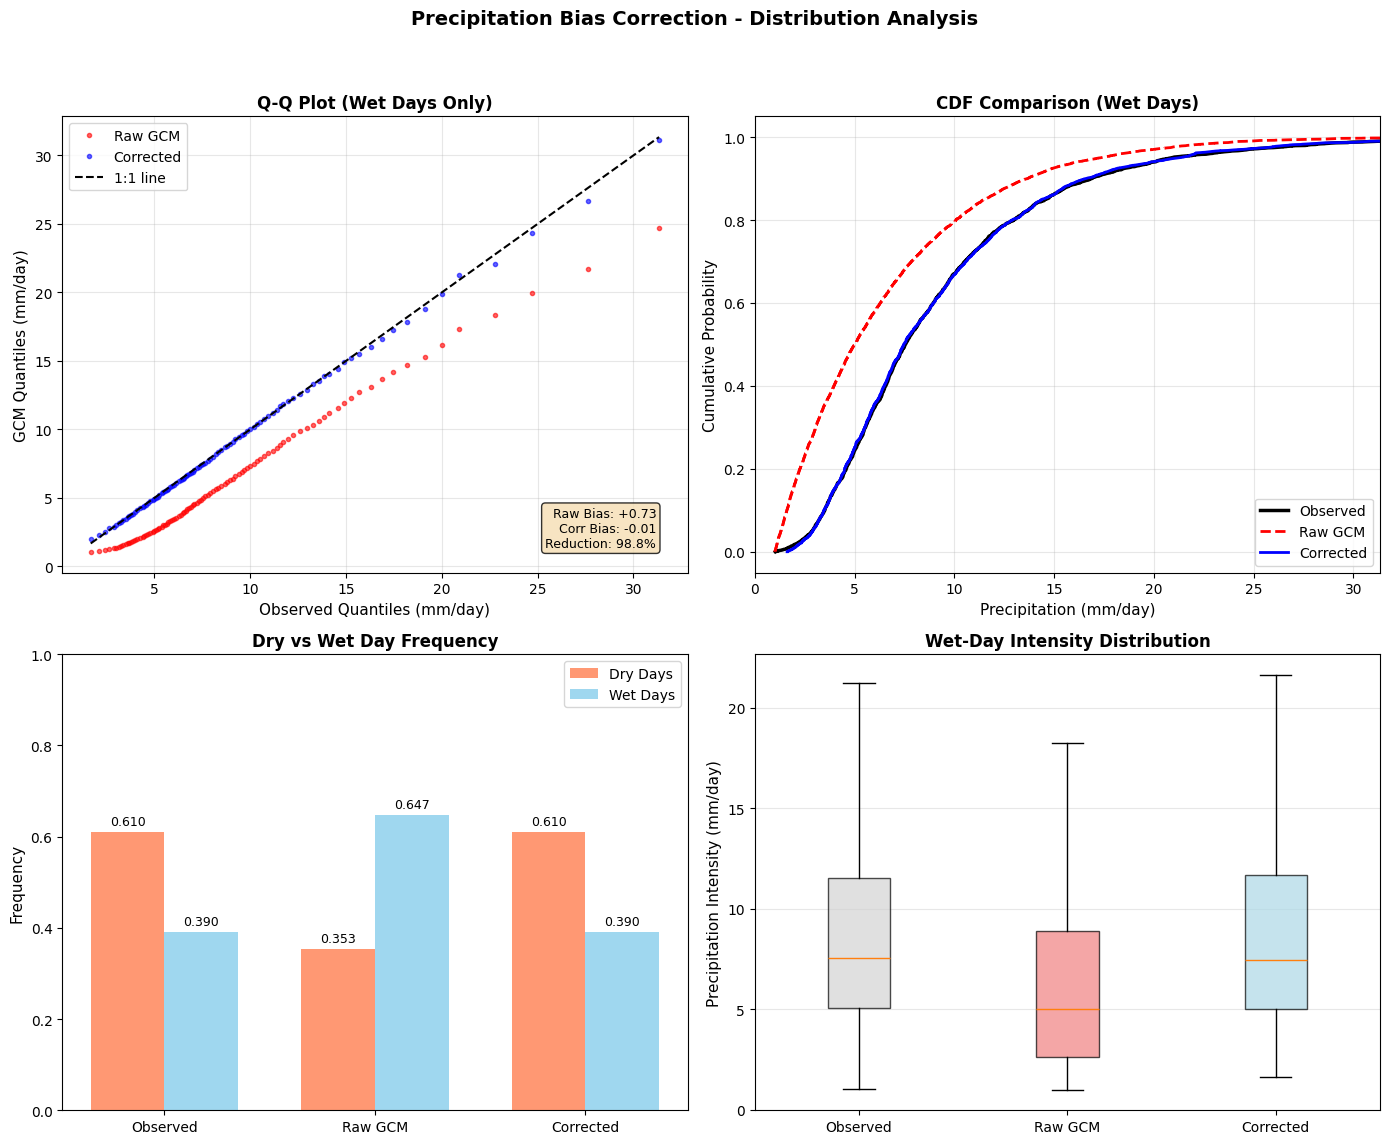

In [23]:
# CELL 6: VISUALIZATION - Q-Q PLOTS AND CDF COMPARISON
# =============================================================================

def plot_precipitation_qq_analysis(df_obs, df_gcm_hist, metrics, config):
    """
    Create Q-Q plots and CDF comparison for precipitation.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('Precipitation Bias Correction - Distribution Analysis', fontsize=14, fontweight='bold')

    pr_col = config['variable_name']
    obs = df_obs[pr_col].values
    raw = df_gcm_hist[pr_col].values
    corr = df_gcm_hist['pr_corrected'].values

    # Filter wet days for visualization
    wet_threshold = config['wet_day_threshold']

    obs_wet = obs[obs > wet_threshold]
    raw_wet = raw[raw > wet_threshold]
    corr_wet = corr[corr > wet_threshold]

    # Plot 1: Q-Q Plot (Wet days only)
    ax1 = axes[0, 0]
    quantiles = np.linspace(0.01, 0.99, 99)

    if len(obs_wet) > 0 and len(raw_wet) > 0 and len(corr_wet) > 0:
        obs_q = np.quantile(obs_wet, quantiles)
        raw_q = np.quantile(raw_wet, quantiles)
        corr_q = np.quantile(corr_wet, quantiles)

        ax1.plot(obs_q, raw_q, 'r.', label='Raw GCM', alpha=0.6, markersize=6)
        ax1.plot(obs_q, corr_q, 'b.', label='Corrected', alpha=0.6, markersize=6)
        ax1.plot([obs_q.min(), obs_q.max()], [obs_q.min(), obs_q.max()],
                 'k--', label='1:1 line', linewidth=1.5)
        ax1.set_xlabel('Observed Quantiles (mm/day)', fontsize=11)
        ax1.set_ylabel('GCM Quantiles (mm/day)', fontsize=11)
        ax1.set_title('Q-Q Plot (Wet Days Only)', fontsize=12, fontweight='bold')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Add metrics text
        textstr = f"Raw Bias: {metrics['bias_raw']:+.2f}\nCorr Bias: {metrics['bias_corr']:+.2f}\nReduction: {metrics['bias_reduction_pct']:.1f}%"
        ax1.text(0.95, 0.05, textstr, transform=ax1.transAxes, fontsize=9,
                 verticalalignment='bottom', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    else:
        ax1.text(0.5, 0.5, 'No wet days found', ha='center', va='center', transform=ax1.transAxes)

    # Plot 2: CDF Comparison (Wet days)
    ax2 = axes[0, 1]
    if len(obs_wet) > 0 and len(raw_wet) > 0 and len(corr_wet) > 0:
        sorted_obs = np.sort(obs_wet)
        sorted_raw = np.sort(raw_wet)
        sorted_corr = np.sort(corr_wet)

        cdf_obs = np.arange(1, len(sorted_obs)+1) / len(sorted_obs)
        cdf_raw = np.arange(1, len(sorted_raw)+1) / len(sorted_raw)
        cdf_corr = np.arange(1, len(sorted_corr)+1) / len(sorted_corr)

        ax2.plot(sorted_obs, cdf_obs, 'k-', label='Observed', linewidth=2.5)
        ax2.plot(sorted_raw, cdf_raw, 'r--', label='Raw GCM', linewidth=2)
        ax2.plot(sorted_corr, cdf_corr, 'b-', label='Corrected', linewidth=2)
        ax2.set_xlabel('Precipitation (mm/day)', fontsize=11)
        ax2.set_ylabel('Cumulative Probability', fontsize=11)
        ax2.set_title('CDF Comparison (Wet Days)', fontsize=12, fontweight='bold')
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(0, np.percentile(obs_wet, 99))
    else:
        ax2.text(0.5, 0.5, 'No wet days found', ha='center', va='center', transform=ax2.transAxes)

    # Plot 3: Dry/Wet Day Frequency
    ax3 = axes[1, 0]
    categories = ['Observed', 'Raw GCM', 'Corrected']
    wet_freqs = [metrics['wet_freq_obs'], metrics['wet_freq_raw'], metrics['wet_freq_corr']]
    dry_freqs = [1-f for f in wet_freqs]

    x = np.arange(len(categories))
    width = 0.35

    bars1 = ax3.bar(x - width/2, dry_freqs, width, label='Dry Days', color='coral', alpha=0.8)
    bars2 = ax3.bar(x + width/2, wet_freqs, width, label='Wet Days', color='skyblue', alpha=0.8)

    ax3.set_ylabel('Frequency', fontsize=11)
    ax3.set_title('Dry vs Wet Day Frequency', fontsize=12, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(categories)
    ax3.legend()
    ax3.set_ylim(0, 1)

    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax3.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    # Plot 4: Intensity Distribution (Box plot)
    ax4 = axes[1, 1]
    if len(obs_wet) > 0 and len(raw_wet) > 0 and len(corr_wet) > 0:
        data_for_box = [obs_wet, raw_wet, corr_wet]
        bp = ax4.boxplot(data_for_box, labels=['Observed', 'Raw GCM', 'Corrected'],
                         patch_artist=True, showfliers=False)

        colors = ['lightgray', 'lightcoral', 'lightblue']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax4.set_ylabel('Precipitation Intensity (mm/day)', fontsize=11)
        ax4.set_title('Wet-Day Intensity Distribution', fontsize=12, fontweight='bold')
        ax4.grid(True, alpha=0.3, axis='y')
    else:
        ax4.text(0.5, 0.5, 'No wet days found', ha='center', va='center', transform=ax4.transAxes)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(config['output_dir'], '01_precipitation_qq_cdf_analysis.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved distribution analysis to: {output_file}")
    plt.show()

# Generate distribution plots
plot_precipitation_qq_analysis(df_obs, df_gcm_hist, metrics, CONFIG)

Saved time series to: /content/drive/MyDrive/Prof_data/output/02_precipitation_timeseries.png


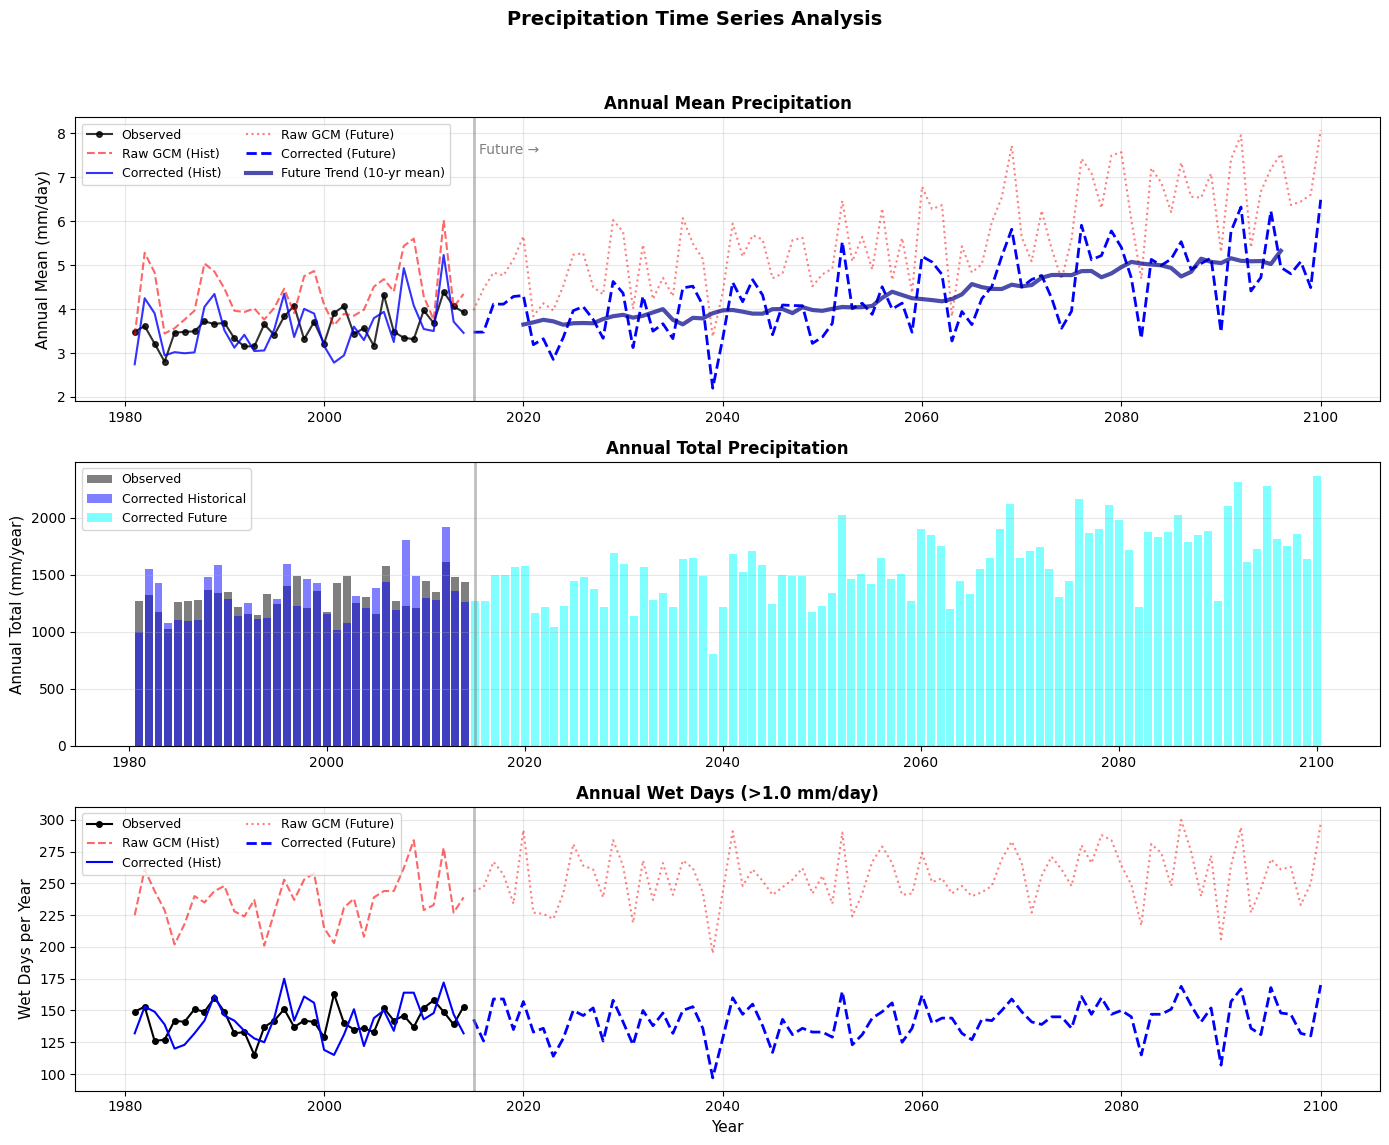

In [24]:
# CELL 7: VISUALIZATION - TIME SERIES ANALYSIS
# =============================================================================

def plot_precipitation_timeseries(df_obs, df_gcm_hist, df_gcm_future, config):
    """
    Create time series plots showing annual and seasonal evolution.
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle('Precipitation Time Series Analysis', fontsize=14, fontweight='bold')

    pr_col = config['variable_name']

    # Calculate annual statistics
    obs_annual = df_obs.groupby('year').agg({
        pr_col: ['mean', 'sum', lambda x: np.sum(x > config['wet_day_threshold'])]
    })
    obs_annual.columns = ['mean', 'total', 'wet_days']

    gcm_hist_annual = df_gcm_hist.groupby('year').agg({
        pr_col: ['mean', 'sum', lambda x: np.sum(x > config['wet_day_threshold'])],
        'pr_corrected': ['mean', 'sum', lambda x: np.sum(x > config['wet_day_threshold'])]
    })
    gcm_hist_annual.columns = ['raw_mean', 'raw_total', 'raw_wet_days',
                               'corr_mean', 'corr_total', 'corr_wet_days']

    gcm_future_annual = df_gcm_future.groupby('year').agg({
        pr_col: ['mean', 'sum', lambda x: np.sum(x > config['wet_day_threshold'])],
        'pr_corrected': ['mean', 'sum', lambda x: np.sum(x > config['wet_day_threshold'])]
    })
    gcm_future_annual.columns = ['raw_mean', 'raw_total', 'raw_wet_days',
                                 'corr_mean', 'corr_total', 'corr_wet_days']

    # Plot 1: Annual Mean Precipitation
    ax1 = axes[0]
    ax1.plot(obs_annual.index, obs_annual['mean'], 'ko-', label='Observed',
             markersize=4, linewidth=1.5, alpha=0.8)
    ax1.plot(gcm_hist_annual.index, gcm_hist_annual['raw_mean'], 'r--',
             label='Raw GCM (Hist)', linewidth=1.5, alpha=0.6)
    ax1.plot(gcm_hist_annual.index, gcm_hist_annual['corr_mean'], 'b-',
             label='Corrected (Hist)', linewidth=1.5, alpha=0.8)
    ax1.plot(gcm_future_annual.index, gcm_future_annual['raw_mean'], 'r:',
             label='Raw GCM (Future)', linewidth=1.5, alpha=0.5)
    ax1.plot(gcm_future_annual.index, gcm_future_annual['corr_mean'], 'b--',
             label='Corrected (Future)', linewidth=2)

    # Add 10-year moving average for future
    ma = gcm_future_annual['corr_mean'].rolling(window=10, center=True).mean()
    ax1.plot(gcm_future_annual.index, ma, color='darkblue', linewidth=3,
             alpha=0.7, label='Future Trend (10-yr mean)')

    ax1.axvline(x=2015, color='gray', linestyle='-', alpha=0.5, linewidth=2)
    ax1.text(2015.5, ax1.get_ylim()[1]*0.9, 'Future →', fontsize=10, color='gray')
    ax1.set_ylabel('Annual Mean (mm/day)', fontsize=11)
    ax1.set_title('Annual Mean Precipitation', fontsize=12, fontweight='bold')
    ax1.legend(loc='upper left', ncol=2, fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Annual Total Precipitation
    ax2 = axes[1]
    ax2.bar(obs_annual.index, obs_annual['total'], alpha=0.5, color='black',
            label='Observed', width=0.8)
    ax2.bar(gcm_hist_annual.index, gcm_hist_annual['corr_total'], alpha=0.5,
            color='blue', label='Corrected Historical', width=0.8)
    ax2.bar(gcm_future_annual.index, gcm_future_annual['corr_total'], alpha=0.5,
            color='cyan', label='Corrected Future', width=0.8)

    ax2.axvline(x=2015, color='gray', linestyle='-', alpha=0.5, linewidth=2)
    ax2.set_ylabel('Annual Total (mm/year)', fontsize=11)
    ax2.set_title('Annual Total Precipitation', fontsize=12, fontweight='bold')
    ax2.legend(loc='upper left', fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Number of Wet Days per Year
    ax3 = axes[2]
    ax3.plot(obs_annual.index, obs_annual['wet_days'], 'ko-', label='Observed',
             markersize=4, linewidth=1.5)
    ax3.plot(gcm_hist_annual.index, gcm_hist_annual['raw_wet_days'], 'r--',
             label='Raw GCM (Hist)', linewidth=1.5, alpha=0.6)
    ax3.plot(gcm_hist_annual.index, gcm_hist_annual['corr_wet_days'], 'b-',
             label='Corrected (Hist)', linewidth=1.5)
    ax3.plot(gcm_future_annual.index, gcm_future_annual['raw_wet_days'], 'r:',
             label='Raw GCM (Future)', linewidth=1.5, alpha=0.5)
    ax3.plot(gcm_future_annual.index, gcm_future_annual['corr_wet_days'], 'b--',
             label='Corrected (Future)', linewidth=2)

    ax3.axvline(x=2015, color='gray', linestyle='-', alpha=0.5, linewidth=2)
    ax3.set_xlabel('Year', fontsize=11)
    ax3.set_ylabel('Wet Days per Year', fontsize=11)
    ax3.set_title(f'Annual Wet Days (>{config["wet_day_threshold"]} mm/day)',
                  fontsize=12, fontweight='bold')
    ax3.legend(loc='upper left', ncol=2, fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(config['output_dir'], '02_precipitation_timeseries.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved time series to: {output_file}")
    plt.show()

plot_precipitation_timeseries(df_obs, df_gcm_hist, df_gcm_future, CONFIG)

Saved seasonal/extreme analysis to: /content/drive/MyDrive/Prof_data/output/03_precipitation_seasonal_extremes.png


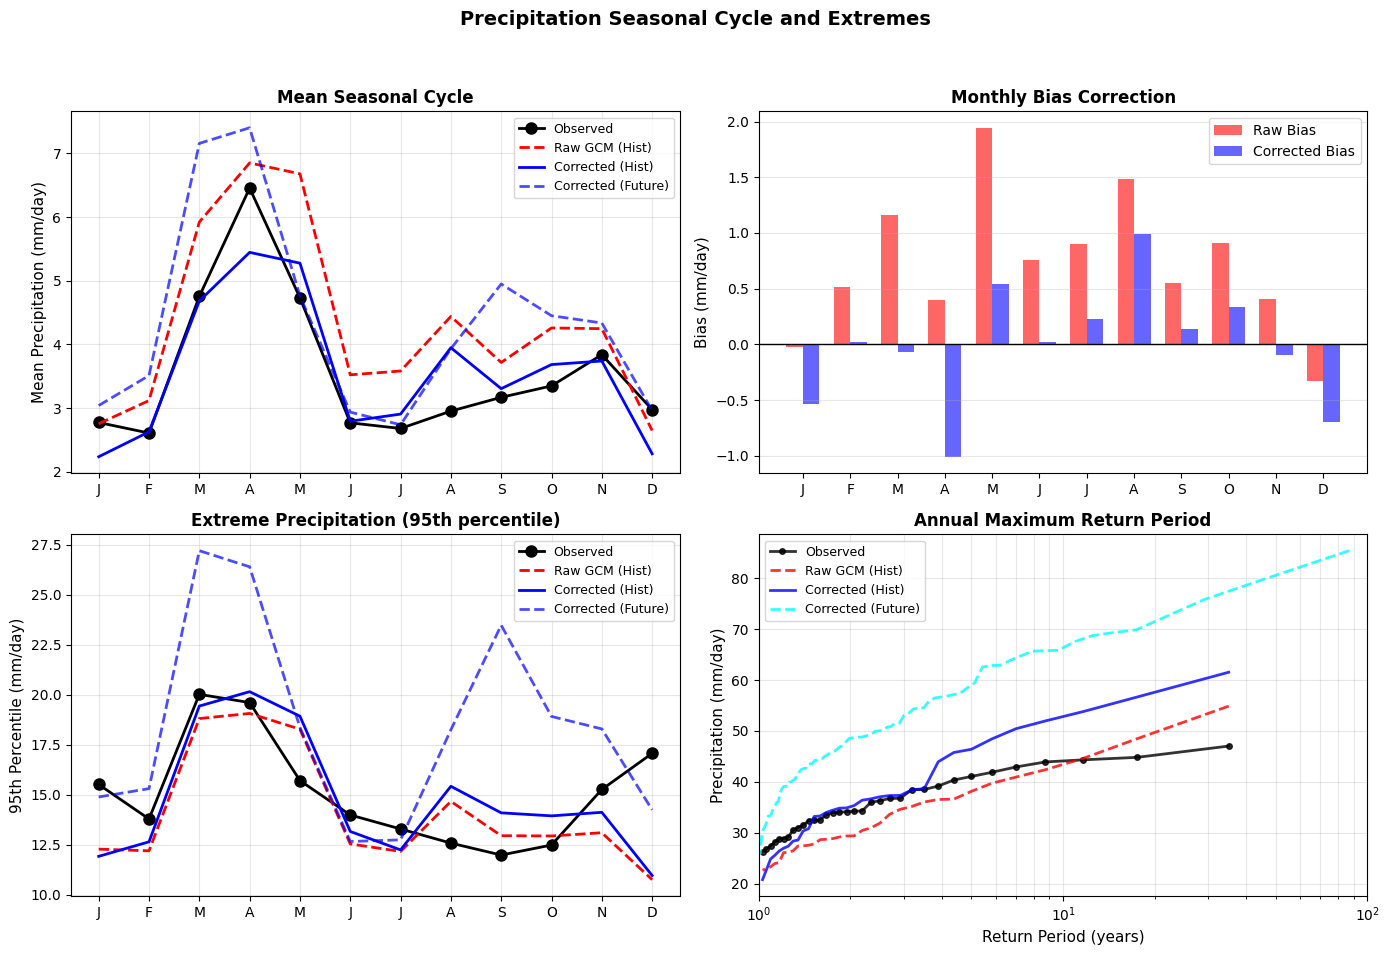

In [25]:
# CELL 8: VISUALIZATION - SEASONAL CYCLE AND EXTREMES
# =============================================================================

def plot_precipitation_seasonal_extremes(df_obs, df_gcm_hist, df_gcm_future, config):
    """
    Analyze seasonal cycle and extreme precipitation events.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Precipitation Seasonal Cycle and Extremes', fontsize=14, fontweight='bold')

    pr_col = config['variable_name']

    # Calculate monthly climatology
    obs_monthly = df_obs.groupby('month')[pr_col].mean()
    hist_raw_monthly = df_gcm_hist.groupby('month')[pr_col].mean()
    hist_corr_monthly = df_gcm_hist.groupby('month')['pr_corrected'].mean()
    future_raw_monthly = df_gcm_future.groupby('month')[pr_col].mean()
    future_corr_monthly = df_gcm_future.groupby('month')['pr_corrected'].mean()

    months = range(1, 13)
    month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

    # Plot 1: Mean Seasonal Cycle
    ax1 = axes[0, 0]
    ax1.plot(months, obs_monthly, 'ko-', label='Observed', linewidth=2, markersize=8)
    ax1.plot(months, hist_raw_monthly, 'r--', label='Raw GCM (Hist)', linewidth=2)
    ax1.plot(months, hist_corr_monthly, 'b-', label='Corrected (Hist)', linewidth=2)
    ax1.plot(months, future_corr_monthly, 'b--', label='Corrected (Future)', linewidth=2, alpha=0.7)

    ax1.set_xticks(months)
    ax1.set_xticklabels(month_names)
    ax1.set_ylabel('Mean Precipitation (mm/day)', fontsize=11)
    ax1.set_title('Mean Seasonal Cycle', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Plot 2: Monthly Bias Correction
    ax2 = axes[0, 1]
    raw_bias = hist_raw_monthly - obs_monthly
    corr_bias = hist_corr_monthly - obs_monthly

    x = np.arange(len(months))
    width = 0.35

    bars1 = ax2.bar(x - width/2, raw_bias, width, label='Raw Bias', color='red', alpha=0.6)
    bars2 = ax2.bar(x + width/2, corr_bias, width, label='Corrected Bias', color='blue', alpha=0.6)

    ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax2.set_xticks(x)
    ax2.set_xticklabels(month_names)
    ax2.set_ylabel('Bias (mm/day)', fontsize=11)
    ax2.set_title('Monthly Bias Correction', fontsize=12, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # Plot 3: Extreme Events (95th percentile by month)
    ax3 = axes[1, 0]

    obs_extreme = df_obs.groupby('month')[pr_col].quantile(0.95)
    hist_raw_extreme = df_gcm_hist.groupby('month')[pr_col].quantile(0.95)
    hist_corr_extreme = df_gcm_hist.groupby('month')['pr_corrected'].quantile(0.95)
    future_corr_extreme = df_gcm_future.groupby('month')['pr_corrected'].quantile(0.95)

    ax3.plot(months, obs_extreme, 'ko-', label='Observed', linewidth=2, markersize=8)
    ax3.plot(months, hist_raw_extreme, 'r--', label='Raw GCM (Hist)', linewidth=2)
    ax3.plot(months, hist_corr_extreme, 'b-', label='Corrected (Hist)', linewidth=2)
    ax3.plot(months, future_corr_extreme, 'b--', label='Corrected (Future)', linewidth=2, alpha=0.7)

    ax3.set_xticks(months)
    ax3.set_xticklabels(month_names)
    ax3.set_ylabel('95th Percentile (mm/day)', fontsize=11)
    ax3.set_title('Extreme Precipitation (95th percentile)', fontsize=12, fontweight='bold')
    ax3.legend(loc='best', fontsize=9)
    ax3.grid(True, alpha=0.3)

    # Plot 4: Return Period Analysis (Annual maxima)
    ax4 = axes[1, 1]

    # Get annual maxima
    obs_annual_max = df_obs.groupby('year')[pr_col].max()
    hist_raw_max = df_gcm_hist.groupby('year')[pr_col].max()
    hist_corr_max = df_gcm_hist.groupby('year')['pr_corrected'].max()
    future_corr_max = df_gcm_future.groupby('year')['pr_corrected'].max()

    def plot_return_period(data, label, color, linestyle, marker=None):
        sorted_data = np.sort(data)[::-1]
        n = len(sorted_data)
        if n == 0:
            return
        return_periods = (n + 1) / np.arange(1, n + 1)
        if marker:
            ax4.semilogx(return_periods, sorted_data, linestyle, label=label,
                        color=color, linewidth=2, alpha=0.8, marker=marker, markersize=4)
        else:
            ax4.semilogx(return_periods, sorted_data, linestyle, label=label,
                        color=color, linewidth=2, alpha=0.8)

    plot_return_period(obs_annual_max, 'Observed', 'black', '-', 'o')
    plot_return_period(hist_raw_max, 'Raw GCM (Hist)', 'red', '--')
    plot_return_period(hist_corr_max, 'Corrected (Hist)', 'blue', '-')
    plot_return_period(future_corr_max, 'Corrected (Future)', 'cyan', '--')

    ax4.set_xlabel('Return Period (years)', fontsize=11)
    ax4.set_ylabel('Precipitation (mm/day)', fontsize=11)
    ax4.set_title('Annual Maximum Return Period', fontsize=12, fontweight='bold')
    ax4.legend(loc='best', fontsize=9)
    ax4.grid(True, alpha=0.3, which='both')
    ax4.set_xlim(1, 100)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(config['output_dir'], '03_precipitation_seasonal_extremes.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Saved seasonal/extreme analysis to: {output_file}")
    plt.show()

plot_precipitation_seasonal_extremes(df_obs, df_gcm_hist, df_gcm_future, CONFIG)

In [26]:
# CELL 9: SAVE OUTPUTS AND FINAL REPORT
# =============================================================================

def save_precipitation_outputs(df_gcm_hist, df_gcm_future, metrics, config):
    """
    Save all corrected data and metrics to files.
    """
    print("\n" + "=" * 70)
    print("STEP 5: SAVING OUTPUTS")
    print("=" * 70)

    # Ensure output directory exists
    os.makedirs(config['output_dir'], exist_ok=True)

    # Save historical corrected data
    hist_output = df_gcm_hist[['date', 'year', 'month', 'day', config['variable_name'], 'pr_corrected']].copy()
    hist_output.columns = ['date', 'year', 'month', 'day', 'pr_raw_mm_day', 'pr_corrected_mm_day']

    hist_file = os.path.join(config['output_dir'], 'precipitation_historical_corrected_1981-2014.csv')
    hist_output.to_csv(hist_file, index=False)
    print(f"Saved historical data: {hist_file}")

    # Save future corrected data
    future_output = df_gcm_future[['date', 'year', 'month', 'day', config['variable_name'], 'pr_corrected']].copy()
    future_output.columns = ['date', 'year', 'month', 'day', 'pr_raw_mm_day', 'pr_corrected_mm_day']

    future_file = os.path.join(config['output_dir'], 'precipitation_future_corrected_2015-2100.csv')
    future_output.to_csv(future_file, index=False)
    print(f"Saved future data: {future_file}")

    # Save metrics
    metrics_df = pd.DataFrame([metrics])
    metrics_file = os.path.join(config['output_dir'], 'precipitation_validation_metrics.csv')
    metrics_df.to_csv(metrics_file, index=False)
    print(f"Saved metrics: {metrics_file}")

    # Generate summary report
    report_file = os.path.join(config['output_dir'], 'precipitation_correction_report.txt')
    with open(report_file, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("PRECIPITATION BIAS CORRECTION REPORT\n")
        f.write("Quantile Delta Mapping - Multiplicative Method\n")
        f.write("=" * 70 + "\n\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")

        f.write("CONFIGURATION:\n")
        f.write(f"  Wet day threshold: {config['wet_day_threshold']} mm/day\n")
        f.write(f"  Number of quantiles: {config.get('n_quantiles', 100)}\n\n")

        f.write("VALIDATION RESULTS (Historical Period 1981-2014):\n")
        f.write(f"  Mean Precipitation:\n")
        f.write(f"    Observed:  {metrics['mean_obs']:.2f} mm/day\n")
        f.write(f"    Raw GCM:   {metrics['mean_raw']:.2f} mm/day (Bias: {metrics['bias_raw']:+.2f})\n")
        f.write(f"    Corrected: {metrics['mean_corr']:.2f} mm/day (Bias: {metrics['bias_corr']:+.2f})\n")
        f.write(f"    Bias Reduction: {metrics['bias_reduction_pct']:.1f}%\n\n")

        f.write(f"  Wet Day Frequency:\n")
        f.write(f"    Observed:  {metrics['wet_freq_obs']:.3f}\n")
        f.write(f"    Raw GCM:   {metrics['wet_freq_raw']:.3f}\n")
        f.write(f"    Corrected: {metrics['wet_freq_corr']:.3f}\n\n")

        f.write(f"  Performance Metrics:\n")
        f.write(f"    RMSE - Raw: {metrics['rmse_raw']:.2f}, Corrected: {metrics['rmse_corr']:.2f}\n")
        f.write(f"    Correlation - Raw: {metrics['corr_raw']:.3f}, Corrected: {metrics['corr_corr']:.3f}\n")
        f.write(f"    KGE - Raw: {metrics['kge_raw']:.3f}, Corrected: {metrics['kge_corr']:.3f}\n\n")

        f.write(f"  Extreme Precipitation (95th percentile):\n")
        f.write(f"    Observed:  {metrics['p95_obs']:.2f} mm/day\n")
        f.write(f"    Raw GCM:   {metrics['p95_raw']:.2f} mm/day\n")
        f.write(f"    Corrected: {metrics['p95_corr']:.2f} mm/day\n")

    print(f"Saved report: {report_file}")
    print("\nAll outputs saved successfully!")

save_precipitation_outputs(df_gcm_hist, df_gcm_future, metrics, CONFIG)

print("\n" + "=" * 70)
print("PRECIPITATION BIAS CORRECTION PIPELINE COMPLETED")
print("=" * 70)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Output directory: {os.path.abspath(CONFIG['output_dir'])}")
print("=" * 70)


STEP 5: SAVING OUTPUTS
Saved historical data: /content/drive/MyDrive/Prof_data/output/precipitation_historical_corrected_1981-2014.csv
Saved future data: /content/drive/MyDrive/Prof_data/output/precipitation_future_corrected_2015-2100.csv
Saved metrics: /content/drive/MyDrive/Prof_data/output/precipitation_validation_metrics.csv
Saved report: /content/drive/MyDrive/Prof_data/output/precipitation_correction_report.txt

All outputs saved successfully!

PRECIPITATION BIAS CORRECTION PIPELINE COMPLETED
End time: 2026-02-12 14:36:48
Output directory: /content/drive/MyDrive/Prof_data/output


In [27]:
# CELL 10: EXTREME PRECIPITATION ANALYSIS - IDF CURVES AND RETURN LEVELS
# =============================================================================
# For Infrastructure Design and Resilience Assessment
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# Define durations for analysis (in hours)
DURATIONS = [24, 48, 72]  # 24h, 48h, 72h

# Return periods for infrastructure design (years)
RETURN_PERIODS = [2, 5, 10, 25, 50, 100]

print("\n" + "=" * 70)
print("EXTREME PRECIPITATION ANALYSIS - IDF CURVES & RETURN LEVELS")
print("For Infrastructure Design and Resilience Assessment")
print("=" * 70)


EXTREME PRECIPITATION ANALYSIS - IDF CURVES & RETURN LEVELS
For Infrastructure Design and Resilience Assessment


In [28]:
# CELL 11: COMPUTE ANNUAL MAXIMA FOR MULTIPLE DURATIONS
# =============================================================================

def compute_annual_maxima(df, durations, pr_col='pr', date_col='date'):
    """
    Compute annual maxima for specified durations using rolling window aggregation.

    Parameters:
    -----------
    df : DataFrame with daily precipitation data
    durations : list of durations in hours (must be multiples of 24 for daily data)
    pr_col : column name for precipitation
    date_col : column name for date

    Returns:
    --------
    dict : Dictionary with annual maxima for each duration
    """
    # Ensure data is sorted by date
    df = df.sort_values(date_col).copy()
    df['year'] = pd.to_datetime(df[date_col]).dt.year

    annual_maxima = {}

    for duration in durations:
        # Convert duration to days (assuming daily data)
        window_size = duration // 24

        if window_size < 1:
            window_size = 1

        # Compute rolling sum for the duration
        df[f'pr_{duration}h'] = df[pr_col].rolling(window=window_size, min_periods=1).sum()

        # Get annual maxima for each year
        annual_max = df.groupby('year')[f'pr_{duration}h'].max().reset_index()
        annual_max['duration'] = duration
        annual_max['intensity'] = annual_max[f'pr_{duration}h'] / duration  # mm/hour

        annual_maxima[duration] = annual_max

        print(f"Duration {duration}h: {len(annual_max)} years of data")
        print(f"  Max depth: {annual_max[f'pr_{duration}h'].max():.1f} mm")
        print(f"  Max intensity: {annual_max['intensity'].max():.2f} mm/h")

    return annual_maxima

# Compute annual maxima for observed data
print("\nComputing annual maxima for OBSERVED data...")
obs_annual_max = compute_annual_maxima(df_obs, DURATIONS, pr_col=CONFIG['variable_name'])

# Compute annual maxima for raw GCM historical
print("\nComputing annual maxima for RAW GCM HISTORICAL data...")
gcm_hist_annual_max = compute_annual_maxima(df_gcm_hist, DURATIONS, pr_col=CONFIG['variable_name'])

# Compute annual maxima for corrected GCM historical
print("\nComputing annual maxima for CORRECTED GCM HISTORICAL data...")
# Create temporary dataframe with corrected precipitation
df_gcm_hist_corrected = df_gcm_hist.copy()
df_gcm_hist_corrected[CONFIG['variable_name']] = df_gcm_hist_corrected['pr_corrected']
gcm_hist_corr_annual_max = compute_annual_maxima(df_gcm_hist_corrected, DURATIONS, pr_col=CONFIG['variable_name'])

# Compute annual maxima for corrected GCM future
print("\nComputing annual maxima for CORRECTED GCM FUTURE data...")
df_gcm_future_corrected = df_gcm_future.copy()
df_gcm_future_corrected[CONFIG['variable_name']] = df_gcm_future_corrected['pr_corrected']
gcm_future_corr_annual_max = compute_annual_maxima(df_gcm_future_corrected, DURATIONS, pr_col=CONFIG['variable_name'])


Computing annual maxima for OBSERVED data...
Duration 24h: 34 years of data
  Max depth: 47.0 mm
  Max intensity: 1.96 mm/h
Duration 48h: 34 years of data
  Max depth: 71.5 mm
  Max intensity: 1.49 mm/h
Duration 72h: 34 years of data
  Max depth: 97.1 mm
  Max intensity: 1.35 mm/h

Computing annual maxima for RAW GCM HISTORICAL data...
Duration 24h: 34 years of data
  Max depth: 54.9 mm
  Max intensity: 2.29 mm/h
Duration 48h: 34 years of data
  Max depth: 73.5 mm
  Max intensity: 1.53 mm/h
Duration 72h: 34 years of data
  Max depth: 92.1 mm
  Max intensity: 1.28 mm/h

Computing annual maxima for CORRECTED GCM HISTORICAL data...
Duration 24h: 34 years of data
  Max depth: 61.5 mm
  Max intensity: 2.56 mm/h
Duration 48h: 34 years of data
  Max depth: 93.2 mm
  Max intensity: 1.94 mm/h
Duration 72h: 34 years of data
  Max depth: 109.8 mm
  Max intensity: 1.53 mm/h

Computing annual maxima for CORRECTED GCM FUTURE data...
Duration 24h: 86 years of data
  Max depth: 85.4 mm
  Max intensit

In [29]:
# CELL 12: FIT GEV DISTRIBUTION TO ANNUAL MAXIMA
# =============================================================================

from scipy.stats import genextreme as gev

def fit_gev_distribution(annual_max_data, duration):
    """
    Fit Generalized Extreme Value (GEV) distribution to annual maxima.

    Parameters:
    -----------
    annual_max_data : DataFrame with annual maxima
    duration : duration in hours

    Returns:
    --------
    dict : GEV parameters and fit statistics
    """
    # Get precipitation depths (not intensity)
    pr_col = f'pr_{duration}h'
    data = annual_max_data[pr_col].values

    # Remove any NaN values
    data = data[~np.isnan(data)]

    if len(data) < 5:
        print(f"WARNING: Insufficient data for duration {duration}h")
        return None

    # Fit GEV distribution
    try:
        # gev.fit returns (shape, location, scale)
        shape, loc, scale = gev.fit(data)

        # Compute goodness-of-fit (Kolmogorov-Smirnov test)
        ks_stat, ks_pvalue = stats.kstest(data, 'genextreme', args=(shape, loc, scale))

        # Compute AIC (Akaike Information Criterion)
        log_likelihood = np.sum(gev.logpdf(data, shape, loc=loc, scale=scale))
        n_params = 3
        aic = 2 * n_params - 2 * log_likelihood

        # Compute return levels for standard return periods
        return_levels = {}
        for T in RETURN_PERIODS:
            # Non-exceedance probability: p = 1 - 1/T
            p = 1 - 1/T
            return_level = gev.ppf(p, shape, loc=loc, scale=scale)
            return_levels[T] = return_level

        result = {
            'duration': duration,
            'shape': shape,
            'location': loc,
            'scale': scale,
            'data': data,
            'n_years': len(data),
            'ks_statistic': ks_stat,
            'ks_pvalue': ks_pvalue,
            'aic': aic,
            'return_levels': return_levels,
            'mean': np.mean(data),
            'std': np.std(data),
            'max_observed': np.max(data)
        }

        print(f"\nDuration {duration}h - GEV Fit Results:")
        print(f"  Shape (ξ): {shape:.4f}")
        print(f"  Location (μ): {loc:.2f} mm")
        print(f"  Scale (σ): {scale:.2f} mm")
        print(f"  KS test p-value: {ks_pvalue:.3f}")
        print(f"  AIC: {aic:.2f}")

        return result

    except Exception as e:
        print(f"ERROR fitting GEV for duration {duration}h: {str(e)}")
        return None

# Fit GEV for all datasets and durations
print("\n" + "=" * 70)
print("FITTING GEV DISTRIBUTIONS")
print("=" * 70)

gev_fits = {
    'observed': {},
    'gcm_hist_raw': {},
    'gcm_hist_corrected': {},
    'gcm_future_corrected': {}
}

for duration in DURATIONS:
    print(f"\n--- Duration: {duration}h ---")

    # Observed
    gev_fits['observed'][duration] = fit_gev_distribution(obs_annual_max[duration], duration)

    # Raw GCM historical
    gev_fits['gcm_hist_raw'][duration] = fit_gev_distribution(gcm_hist_annual_max[duration], duration)

    # Corrected GCM historical
    gev_fits['gcm_hist_corrected'][duration] = fit_gev_distribution(gcm_hist_corr_annual_max[duration], duration)

    # Corrected GCM future
    gev_fits['gcm_future_corrected'][duration] = fit_gev_distribution(gcm_future_corr_annual_max[duration], duration)


FITTING GEV DISTRIBUTIONS

--- Duration: 24h ---

Duration 24h - GEV Fit Results:
  Shape (ξ): 0.1611
  Location (μ): 32.96 mm
  Scale (σ): 5.06 mm
  KS test p-value: 0.908
  AIC: 217.98

Duration 24h - GEV Fit Results:
  Shape (ξ): -0.1655
  Location (μ): 28.40 mm
  Scale (σ): 5.03 mm
  KS test p-value: 0.914
  AIC: 229.82

Duration 24h - GEV Fit Results:
  Shape (ξ): 0.0259
  Location (μ): 32.35 mm
  Scale (σ): 8.07 mm
  KS test p-value: 0.855
  AIC: 254.70

Duration 24h - GEV Fit Results:
  Shape (ξ): 0.1002
  Location (μ): 44.43 mm
  Scale (σ): 10.39 mm
  KS test p-value: 0.972
  AIC: 670.50

--- Duration: 48h ---

Duration 48h - GEV Fit Results:
  Shape (ξ): 0.1783
  Location (μ): 47.83 mm
  Scale (σ): 8.68 mm
  KS test p-value: 0.344
  AIC: 254.20

Duration 48h - GEV Fit Results:
  Shape (ξ): 0.1222
  Location (μ): 46.57 mm
  Scale (σ): 8.45 mm
  KS test p-value: 0.957
  AIC: 253.86

Duration 48h - GEV Fit Results:
  Shape (ξ): 0.0691
  Location (μ): 49.09 mm
  Scale (σ): 11.84 

In [30]:
# CELL 13: CALCULATE IDF CURVES (INTENSITY-DURATION-FREQUENCY)
# =============================================================================

def calculate_idf_curves(gev_fits_dict, return_periods, durations):
    """
    Calculate IDF curves from fitted GEV distributions.

    Returns intensity (mm/h) for each duration and return period.
    """
    idf_data = []

    for dataset_name, fits in gev_fits_dict.items():
        for T in return_periods:
            intensities = []
            valid_durations = []

            for duration in durations:
                if fits[duration] is not None:
                    # Get return level in mm
                    return_level_mm = fits[duration]['return_levels'][T]
                    # Convert to intensity (mm/h)
                    intensity = return_level_mm / duration
                    intensities.append(intensity)
                    valid_durations.append(duration)

            for i, duration in enumerate(valid_durations):
                idf_data.append({
                    'dataset': dataset_name,
                    'return_period': T,
                    'duration': duration,
                    'intensity': intensities[i],
                    'depth': intensities[i] * duration  # total depth in mm
                })

    return pd.DataFrame(idf_data)

# Calculate IDF curves
print("\n" + "=" * 70)
print("CALCULATING IDF CURVES")
print("=" * 70)

idf_df = calculate_idf_curves(gev_fits, RETURN_PERIODS, DURATIONS)

# Display IDF table
print("\nIDF Curves - Intensity (mm/h) by Duration and Return Period:")
print("-" * 70)

for dataset in ['observed', 'gcm_hist_raw', 'gcm_hist_corrected', 'gcm_future_corrected']:
    print(f"\n{dataset.upper()}:")
    subset = idf_df[idf_df['dataset'] == dataset]
    pivot = subset.pivot(index='duration', columns='return_period', values='intensity')
    print(pivot.round(2))


CALCULATING IDF CURVES

IDF Curves - Intensity (mm/h) by Duration and Return Period:
----------------------------------------------------------------------

OBSERVED:
return_period   2     5     10    25    50    100
duration                                         
24             1.45  1.65  1.77  1.90  1.98  2.06
48             1.06  1.23  1.33  1.44  1.50  1.56
72             0.90  1.06  1.16  1.28  1.36  1.44

GCM_HIST_RAW:
return_period   2     5     10    25    50    100
duration                                         
24             1.26  1.54  1.76  2.07  2.33  2.63
48             1.03  1.21  1.32  1.44  1.52  1.59
72             0.91  1.07  1.16  1.26  1.33  1.39

GCM_HIST_CORRECTED:
return_period   2     5     10    25    50    100
duration                                         
24             1.47  1.84  2.08  2.38  2.60  2.81
48             1.11  1.37  1.54  1.73  1.87  1.99
72             0.93  1.13  1.25  1.39  1.48  1.57

GCM_FUTURE_CORRECTED:
return_period   2     5

In [31]:
# CELL 14: RETURN LEVELS WITH CONFIDENCE INTERVALS
# =============================================================================

def calculate_return_levels_with_ci(gev_fit, return_periods, confidence=0.95):
    """
    Calculate return levels with confidence intervals using delta method.
    """
    if gev_fit is None:
        return None

    shape = gev_fit['shape']
    loc = gev_fit['location']
    scale = gev_fit['scale']
    n = gev_fit['n_years']

    # Fisher information matrix approximation (simplified)
    # For more accurate CIs, use bootstrap or profile likelihood

    return_levels = {}

    for T in return_periods:
        p = 1 - 1/T
        # Point estimate
        rl = gev.ppf(p, shape, loc=loc, scale=scale)

        # Approximate standard error using delta method
        # This is a simplified approximation
        se = scale / np.sqrt(n) * np.sqrt(1 + shape**2)  # Simplified SE

        # Confidence interval
        z = stats.norm.ppf((1 + confidence) / 2)
        ci_lower = rl - z * se
        ci_upper = rl + z * se

        return_levels[T] = {
            'return_level': rl,
            'ci_lower': max(0, ci_lower),  # Ensure non-negative
            'ci_upper': ci_upper,
            'se': se
        }

    return return_levels

# Calculate return levels with confidence intervals
print("\n" + "=" * 70)
print("RETURN LEVELS WITH 95% CONFIDENCE INTERVALS")
print("=" * 70)

return_levels_ci = {}

for dataset_name, fits in gev_fits.items():
    return_levels_ci[dataset_name] = {}
    print(f"\n{dataset_name.upper()}:")

    for duration in DURATIONS:
        if fits[duration] is not None:
            rl_ci = calculate_return_levels_with_ci(fits[duration], RETURN_PERIODS)
            return_levels_ci[dataset_name][duration] = rl_ci

            print(f"\n  Duration {duration}h:")
            for T in RETURN_PERIODS:
                rl = rl_ci[T]['return_level']
                lower = rl_ci[T]['ci_lower']
                upper = rl_ci[T]['ci_upper']
                print(f"    {T}-year: {rl:.1f} mm ({lower:.1f} - {upper:.1f} mm)")


RETURN LEVELS WITH 95% CONFIDENCE INTERVALS

OBSERVED:

  Duration 24h:
    2-year: 34.8 mm (33.0 - 36.5 mm)
    5-year: 39.7 mm (38.0 - 41.4 mm)
    10-year: 42.5 mm (40.8 - 44.2 mm)
    25-year: 45.6 mm (43.9 - 47.3 mm)
    50-year: 47.6 mm (45.9 - 49.3 mm)
    100-year: 49.4 mm (47.7 - 51.1 mm)

  Duration 48h:
    2-year: 50.9 mm (47.9 - 53.9 mm)
    5-year: 59.2 mm (56.3 - 62.2 mm)
    10-year: 63.9 mm (61.0 - 66.9 mm)
    25-year: 69.0 mm (66.0 - 71.9 mm)
    50-year: 72.2 mm (69.3 - 75.2 mm)
    100-year: 75.1 mm (72.1 - 78.0 mm)

  Duration 72h:
    2-year: 64.6 mm (60.9 - 68.2 mm)
    5-year: 76.2 mm (72.5 - 79.8 mm)
    10-year: 83.4 mm (79.7 - 87.1 mm)
    25-year: 92.0 mm (88.4 - 95.7 mm)
    50-year: 98.1 mm (94.5 - 101.8 mm)
    100-year: 103.9 mm (100.3 - 107.6 mm)

GCM_HIST_RAW:

  Duration 24h:
    2-year: 30.3 mm (28.6 - 32.0 mm)
    5-year: 37.0 mm (35.3 - 38.7 mm)
    10-year: 42.1 mm (40.4 - 43.8 mm)
    25-year: 49.6 mm (47.9 - 51.3 mm)
    50-year: 56.0 mm (54.3


Saved IDF curves to: /content/drive/MyDrive/Prof_data/output/04_idf_curves_infrastructure_design.png


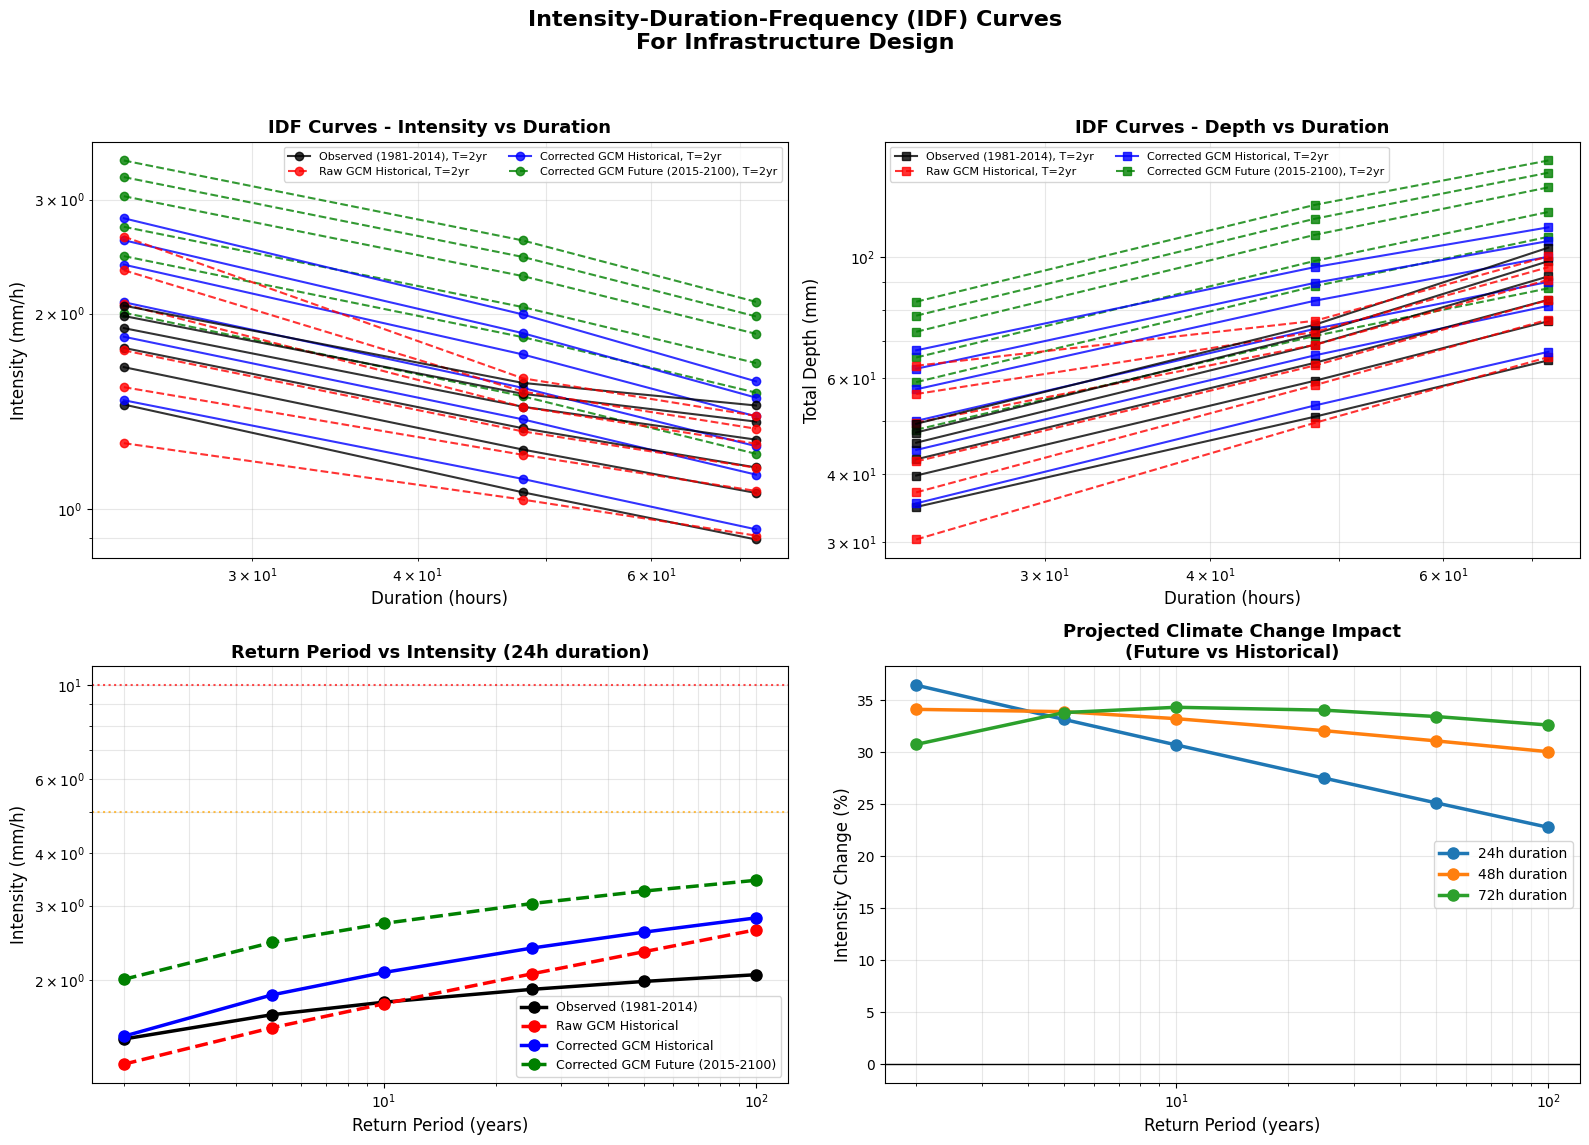

In [32]:
# CELL 15: PLOT IDF CURVES FOR INFRASTRUCTURE DESIGN
# =============================================================================

def plot_idf_curves(idf_df, output_dir):
    """
    Create IDF curve plots for infrastructure design.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Intensity-Duration-Frequency (IDF) Curves\nFor Infrastructure Design',
                 fontsize=16, fontweight='bold')

    datasets = {
        'observed': ('Observed (1981-2014)', 'black', '-'),
        'gcm_hist_raw': ('Raw GCM Historical', 'red', '--'),
        'gcm_hist_corrected': ('Corrected GCM Historical', 'blue', '-'),
        'gcm_future_corrected': ('Corrected GCM Future (2015-2100)', 'green', '--')
    }

    # Plot 1: IDF Curves - Intensity vs Duration for different return periods
    ax1 = axes[0, 0]
    colors_rp = plt.cm.viridis(np.linspace(0, 1, len(RETURN_PERIODS)))

    for i, T in enumerate(RETURN_PERIODS):
        for dataset, (label, color, linestyle) in datasets.items():
            subset = idf_df[(idf_df['dataset'] == dataset) & (idf_df['return_period'] == T)]
            if not subset.empty:
                ax1.plot(subset['duration'], subset['intensity'],
                        linestyle=linestyle, color=color,
                        label=f'{label}, T={T}yr' if i == 0 else "",
                        marker='o', markersize=6, alpha=0.8)

    ax1.set_xlabel('Duration (hours)', fontsize=12)
    ax1.set_ylabel('Intensity (mm/h)', fontsize=12)
    ax1.set_title('IDF Curves - Intensity vs Duration', fontsize=13, fontweight='bold')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.3, which='both')
    ax1.legend(loc='upper right', fontsize=8, ncol=2)

    # Plot 2: IDF Curves - Depth vs Duration
    ax2 = axes[0, 1]
    for i, T in enumerate(RETURN_PERIODS):
        for dataset, (label, color, linestyle) in datasets.items():
            subset = idf_df[(idf_df['dataset'] == dataset) & (idf_df['return_period'] == T)]
            if not subset.empty:
                ax2.plot(subset['duration'], subset['depth'],
                        linestyle=linestyle, color=color,
                        label=f'{label}, T={T}yr' if i == 0 else "",
                        marker='s', markersize=6, alpha=0.8)

    ax2.set_xlabel('Duration (hours)', fontsize=12)
    ax2.set_ylabel('Total Depth (mm)', fontsize=12)
    ax2.set_title('IDF Curves - Depth vs Duration', fontsize=13, fontweight='bold')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3, which='both')
    ax2.legend(loc='upper left', fontsize=8, ncol=2)

    # Plot 3: Return Period vs Intensity for 24h duration
    ax3 = axes[1, 0]
    duration_focus = 24

    for dataset, (label, color, linestyle) in datasets.items():
        subset = idf_df[(idf_df['dataset'] == dataset) & (idf_df['duration'] == duration_focus)]
        if not subset.empty:
            ax3.plot(subset['return_period'], subset['intensity'],
                    linestyle=linestyle, color=color, label=label,
                    marker='o', markersize=8, linewidth=2.5)

    ax3.set_xlabel('Return Period (years)', fontsize=12)
    ax3.set_ylabel('Intensity (mm/h)', fontsize=12)
    ax3.set_title(f'Return Period vs Intensity ({duration_focus}h duration)',
                  fontsize=13, fontweight='bold')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.3, which='both')
    ax3.legend(loc='lower right', fontsize=9)

    # Add infrastructure design thresholds
    ax3.axhline(y=5, color='orange', linestyle=':', alpha=0.7, label='Minor structures')
    ax3.axhline(y=10, color='red', linestyle=':', alpha=0.7, label='Major infrastructure')

    # Plot 4: Climate Change Impact - Future vs Historical
    ax4 = axes[1, 1]

    hist_subset = idf_df[idf_df['dataset'] == 'gcm_hist_corrected']
    future_subset = idf_df[idf_df['dataset'] == 'gcm_future_corrected']

    for duration in DURATIONS:
        h_data = hist_subset[hist_subset['duration'] == duration]
        f_data = future_subset[future_subset['duration'] == duration]

        if not h_data.empty and not f_data.empty:
            # Merge on return period
            merged = pd.merge(h_data, f_data, on='return_period', suffixes=('_hist', '_future'))
            merged['change_pct'] = ((merged['intensity_future'] - merged['intensity_hist'])
                                   / merged['intensity_hist'] * 100)

            ax4.plot(merged['return_period'], merged['change_pct'],
                    marker='o', markersize=8, linewidth=2.5,
                    label=f'{duration}h duration')

    ax4.set_xlabel('Return Period (years)', fontsize=12)
    ax4.set_ylabel('Intensity Change (%)', fontsize=12)
    ax4.set_title('Projected Climate Change Impact\n(Future vs Historical)',
                  fontsize=13, fontweight='bold')
    ax4.set_xscale('log')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax4.grid(True, alpha=0.3, which='both')
    ax4.legend(loc='best', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(output_dir, '04_idf_curves_infrastructure_design.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved IDF curves to: {output_file}")
    plt.show()

# Generate IDF plots
plot_idf_curves(idf_df, CONFIG['output_dir'])


Saved return level plots to: /content/drive/MyDrive/Prof_data/output/05_return_levels_with_ci.png


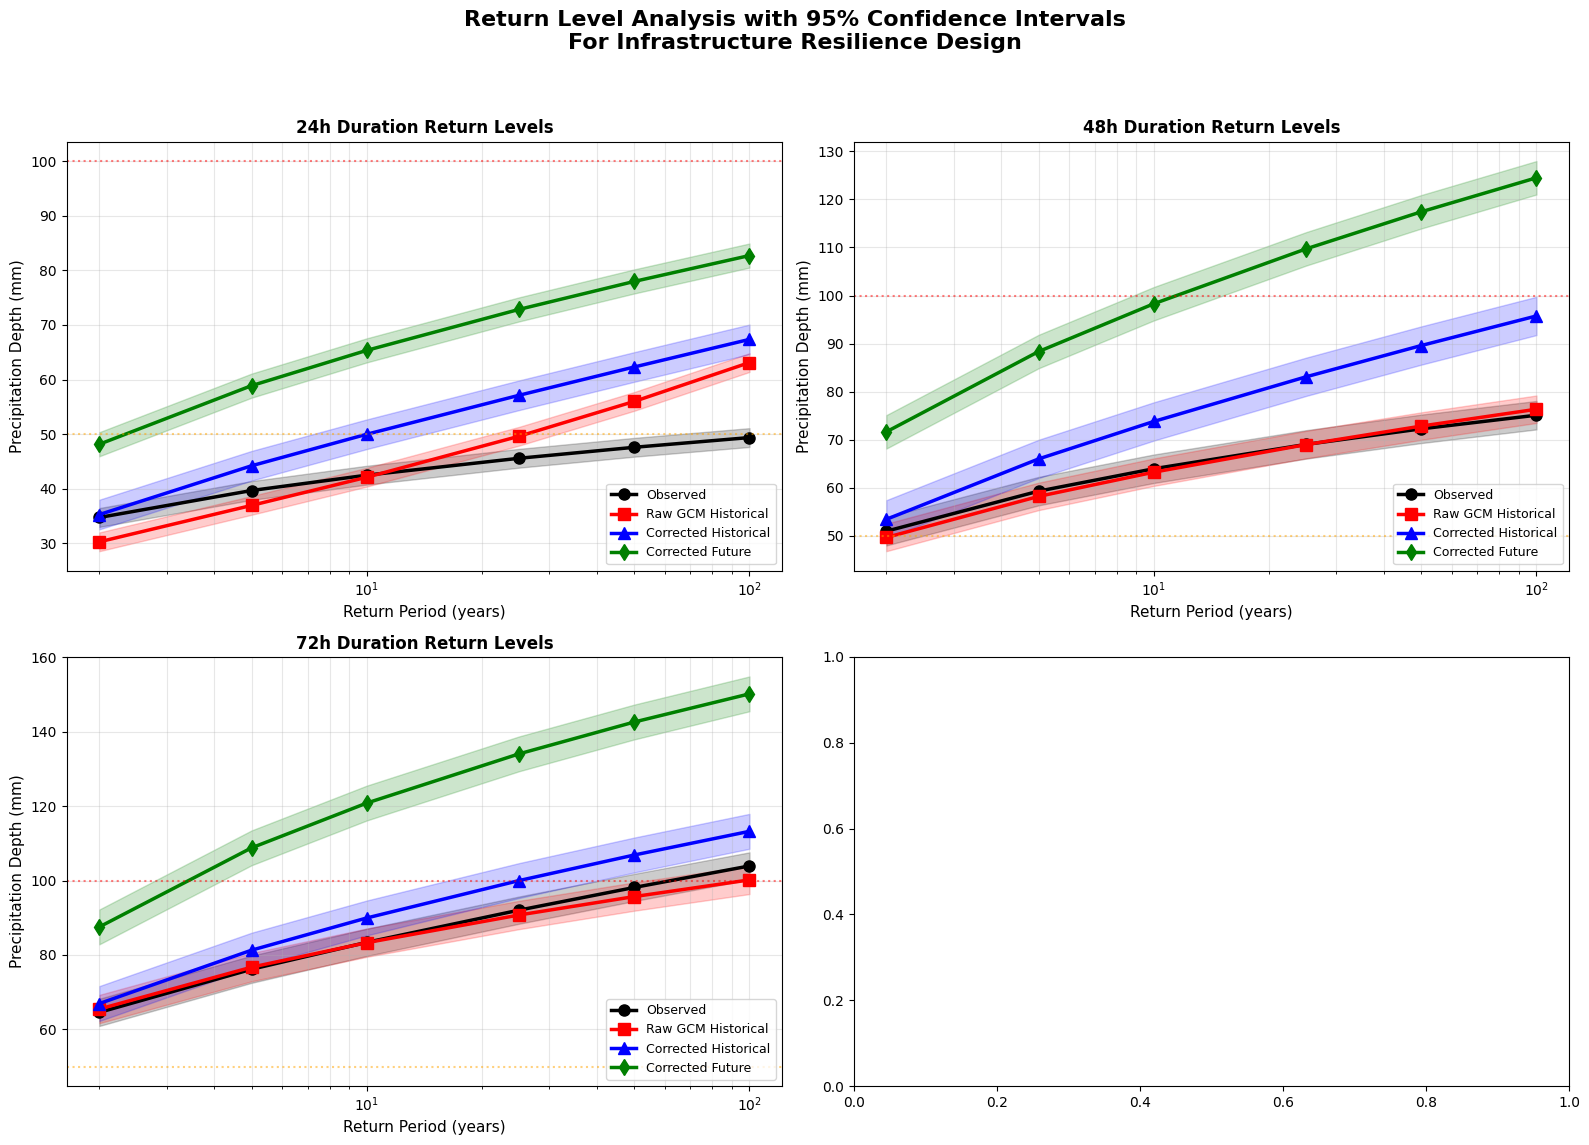

In [33]:
# CELL 16: RETURN LEVEL PLOTS WITH UNCERTAINTY BOUNDS
# =============================================================================

def plot_return_levels_with_ci(gev_fits, return_levels_ci, output_dir):
    """
    Create return level plots with confidence intervals for infrastructure design.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Return Level Analysis with 95% Confidence Intervals\nFor Infrastructure Resilience Design',
                 fontsize=16, fontweight='bold')

    datasets = {
        'observed': ('Observed', 'black', 'o'),
        'gcm_hist_raw': ('Raw GCM Historical', 'red', 's'),
        'gcm_hist_corrected': ('Corrected Historical', 'blue', '^'),
        'gcm_future_corrected': ('Corrected Future', 'green', 'd')
    }

    # Plot for each duration
    for idx, duration in enumerate(DURATIONS):
        if idx >= 4:
            break

        ax = axes[idx // 2, idx % 2]

        for dataset, (label, color, marker) in datasets.items():
            if (dataset in return_levels_ci and
                duration in return_levels_ci[dataset] and
                return_levels_ci[dataset][duration] is not None):

                rl_data = return_levels_ci[dataset][duration]

                periods = []
                levels = []
                ci_lower = []
                ci_upper = []

                for T in RETURN_PERIODS:
                    if T in rl_data:
                        periods.append(T)
                        levels.append(rl_data[T]['return_level'])
                        ci_lower.append(rl_data[T]['ci_lower'])
                        ci_upper.append(rl_data[T]['ci_upper'])

                if len(periods) > 0:
                    # Plot confidence interval as shaded area
                    ax.fill_between(periods, ci_lower, ci_upper,
                                   alpha=0.2, color=color)

                    # Plot point estimates
                    ax.plot(periods, levels, linestyle='-', color=color,
                           marker=marker, markersize=8, linewidth=2.5,
                           label=label)

        ax.set_xlabel('Return Period (years)', fontsize=11)
        ax.set_ylabel('Precipitation Depth (mm)', fontsize=11)
        ax.set_title(f'{duration}h Duration Return Levels', fontsize=12, fontweight='bold')
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3, which='both')
        ax.legend(loc='lower right', fontsize=9)

        # Add design thresholds
        ax.axhline(y=50, color='orange', linestyle=':', alpha=0.5, label='Urban drainage')
        ax.axhline(y=100, color='red', linestyle=':', alpha=0.5, label='Flood protection')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_file = os.path.join(output_dir, '05_return_levels_with_ci.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved return level plots to: {output_file}")
    plt.show()

# Generate return level plots
plot_return_levels_with_ci(gev_fits, return_levels_ci, CONFIG['output_dir'])

In [34]:
# CELL 17: GENERATE INFRASTRUCTURE DESIGN SUMMARY TABLE
# =============================================================================

def create_infrastructure_design_table(idf_df, return_levels_ci, output_dir):
    """
    Create comprehensive design tables for infrastructure engineers.
    """
    print("\n" + "=" * 70)
    print("INFRASTRUCTURE DESIGN RECOMMENDATIONS")
    print("=" * 70)

    # Create design table for different infrastructure types
    infrastructure_designs = []

    # Define infrastructure types and their design return periods
    infra_types = {
        'Urban Drainage (Minor)': 5,
        'Urban Drainage (Major)': 10,
        'Road Culverts': 25,
        'Bridges': 50,
        'Dam Spillways': 100,
        'Critical Infrastructure': 100
    }

    for infra_name, design_T in infra_types.items():
        for duration in DURATIONS:
            # Get values from corrected future (for climate-resilient design)
            future_data = idf_df[(idf_df['dataset'] == 'gcm_future_corrected') &
                                (idf_df['duration'] == duration) &
                                (idf_df['return_period'] == design_T)]

            hist_data = idf_df[(idf_df['dataset'] == 'gcm_hist_corrected') &
                              (idf_df['duration'] == duration) &
                              (idf_df['return_period'] == design_T)]

            obs_data = idf_df[(idf_df['dataset'] == 'observed') &
                             (idf_df['duration'] == duration) &
                             (idf_df['return_period'] == design_T)]

            if not future_data.empty:
                intensity_future = future_data['intensity'].values[0]
                depth_future = future_data['depth'].values[0]

                intensity_hist = hist_data['intensity'].values[0] if not hist_data.empty else np.nan
                depth_hist = hist_data['depth'].values[0] if not hist_data.empty else np.nan

                intensity_obs = obs_data['intensity'].values[0] if not obs_data.empty else np.nan

                # Calculate climate change amplification
                if not np.isnan(intensity_hist) and intensity_hist > 0:
                    amplification = (intensity_future - intensity_hist) / intensity_hist * 100
                else:
                    amplification = np.nan

                infrastructure_designs.append({
                    'Infrastructure_Type': infra_name,
                    'Design_Return_Period_yr': design_T,
                    'Duration_h': duration,
                    'Intensity_mm_h': round(intensity_future, 2),
                    'Total_Depth_mm': round(depth_future, 1),
                    'Historical_Intensity_mm_h': round(intensity_hist, 2) if not np.isnan(intensity_hist) else None,
                    'Observed_Intensity_mm_h': round(intensity_obs, 2) if not np.isnan(intensity_obs) else None,
                    'Climate_Change_Amplification_pct': round(amplification, 1) if not np.isnan(amplification) else None,
                    'Design_Category': 'Climate-Resilient' if amplification > 10 else 'Standard'
                })

    design_df = pd.DataFrame(infrastructure_designs)

    # Save to CSV
    output_file = os.path.join(output_dir, 'infrastructure_design_recommendations.csv')
    design_df.to_csv(output_file, index=False)
    print(f"\nSaved infrastructure design table to: {output_file}")

    # Display table
    print("\n" + "=" * 70)
    print("CLIMATE-RESILIENT INFRASTRUCTURE DESIGN VALUES")
    print("Projected Future Climate (2015-2100) - Corrected GCM")
    print("=" * 70)

    for infra in infra_types.keys():
        print(f"\n{infra} (T={infra_types[infra]} years):")
        subset = design_df[design_df['Infrastructure_Type'] == infra]
        for _, row in subset.iterrows():
            print(f"  {row['Duration_h']}h: {row['Intensity_mm_h']:.2f} mm/h "
                  f"({row['Total_Depth_mm']:.1f} mm total)")
            if row['Climate_Change_Amplification_pct'] is not None:
                print(f"    → Climate change amplification: +{row['Climate_Change_Amplification_pct']:.1f}%")

    return design_df

# Generate design table
design_table = create_infrastructure_design_table(idf_df, return_levels_ci, CONFIG['output_dir'])


INFRASTRUCTURE DESIGN RECOMMENDATIONS

Saved infrastructure design table to: /content/drive/MyDrive/Prof_data/output/infrastructure_design_recommendations.csv

CLIMATE-RESILIENT INFRASTRUCTURE DESIGN VALUES
Projected Future Climate (2015-2100) - Corrected GCM

Urban Drainage (Minor) (T=5 years):
  24h: 2.45 mm/h (58.9 mm total)
    → Climate change amplification: +33.2%
  48h: 1.84 mm/h (88.3 mm total)
    → Climate change amplification: +33.9%
  72h: 1.51 mm/h (108.8 mm total)
    → Climate change amplification: +33.8%

Urban Drainage (Major) (T=10 years):
  24h: 2.72 mm/h (65.3 mm total)
    → Climate change amplification: +30.7%
  48h: 2.05 mm/h (98.3 mm total)
    → Climate change amplification: +33.2%
  72h: 1.68 mm/h (120.8 mm total)
    → Climate change amplification: +34.3%

Road Culverts (T=25 years):
  24h: 3.04 mm/h (72.8 mm total)
    → Climate change amplification: +27.5%
  48h: 2.29 mm/h (109.7 mm total)
    → Climate change amplification: +32.1%
  72h: 1.86 mm/h (134.0 

In [35]:
# CELL 18: SAVE COMPREHENSIVE EXTREME PRECIPITATION REPORT
# =============================================================================

def save_extreme_precipitation_report(gev_fits, idf_df, return_levels_ci, design_table, config):
    """
    Save comprehensive report for infrastructure design.
    """
    print("\n" + "=" * 70)
    print("SAVING EXTREME PRECIPITATION ANALYSIS REPORT")
    print("=" * 70)

    report_file = os.path.join(config['output_dir'], 'extreme_precipitation_idf_report.txt')

    with open(report_file, 'w') as f:
        f.write("=" * 80 + "\n")
        f.write("EXTREME PRECIPITATION ANALYSIS - IDF CURVES & RETURN LEVELS\n")
        f.write("For Infrastructure Design and Climate Resilience Assessment\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Analysis Periods: Historical (1981-2014) | Future (2015-2100)\n")
        f.write(f"Durations Analyzed: {', '.join([str(d) + 'h' for d in DURATIONS])}\n")
        f.write(f"Return Periods: {', '.join([str(T) + '-yr' for T in RETURN_PERIODS])}\n\n")

        f.write("=" * 80 + "\n")
        f.write("SECTION 1: GEV DISTRIBUTION FIT RESULTS\n")
        f.write("=" * 80 + "\n\n")

        for dataset_name, fits in gev_fits.items():
            f.write(f"\n{dataset_name.upper().replace('_', ' ')}:\n")
            f.write("-" * 40 + "\n")
            for duration in DURATIONS:
                if fits[duration] is not None:
                    fit = fits[duration]
                    f.write(f"\n  {duration}h Duration:\n")
                    f.write(f"    Shape (ξ): {fit['shape']:.4f}\n")
                    f.write(f"    Location (μ): {fit['location']:.2f} mm\n")
                    f.write(f"    Scale (σ): {fit['scale']:.2f} mm\n")
                    f.write(f"    Mean: {fit['mean']:.2f} mm\n")
                    f.write(f"    Max Observed: {fit['max_observed']:.2f} mm\n")
                    f.write(f"    KS p-value: {fit['ks_pvalue']:.3f}\n")

        f.write("\n\n" + "=" * 80 + "\n")
        f.write("SECTION 2: RETURN LEVELS (mm) BY DURATION AND RETURN PERIOD\n")
        f.write("=" * 80 + "\n\n")

        for dataset_name in ['observed', 'gcm_hist_corrected', 'gcm_future_corrected']:
            f.write(f"\n{dataset_name.upper().replace('_', ' ')}:\n")
            f.write("-" * 50 + "\n")

            for duration in DURATIONS:
                f.write(f"\n  {duration}h Duration:\n")
                if (dataset_name in return_levels_ci and
                    duration in return_levels_ci[dataset_name] and
                    return_levels_ci[dataset_name][duration] is not None):

                    for T in RETURN_PERIODS:
                        rl_data = return_levels_ci[dataset_name][duration][T]
                        f.write(f"    {T:3d}-year: {rl_data['return_level']:6.1f} mm "
                               f"({rl_data['ci_lower']:6.1f} - {rl_data['ci_upper']:6.1f} mm)\n")

        f.write("\n\n" + "=" * 80 + "\n")
        f.write("SECTION 3: IDF CURVES - INTENSITY (mm/h)\n")
        f.write("=" * 80 + "\n\n")

        for dataset_name in ['observed', 'gcm_hist_corrected', 'gcm_future_corrected']:
            f.write(f"\n{dataset_name.upper().replace('_', ' ')}:\n")
            subset = idf_df[idf_df['dataset'] == dataset_name]
            pivot = subset.pivot(index='duration', columns='return_period', values='intensity')
            f.write(pivot.round(2).to_string())
            f.write("\n")

        f.write("\n\n" + "=" * 80 + "\n")
        f.write("SECTION 4: INFRASTRUCTURE DESIGN RECOMMENDATIONS\n")
        f.write("Climate-Resilient Design Values (Future Climate)\n")
        f.write("=" * 80 + "\n\n")

        for infra_type in design_table['Infrastructure_Type'].unique():
            f.write(f"\n{infra_type}:\n")
            f.write("-" * 50 + "\n")
            subset = design_table[design_table['Infrastructure_Type'] == infra_type]
            for _, row in subset.iterrows():
                f.write(f"  {row['Duration_h']}h duration:\n")
                f.write(f"    Design Intensity: {row['Intensity_mm_h']:.2f} mm/h\n")
                f.write(f"    Total Depth: {row['Total_Depth_mm']:.1f} mm\n")
                if row['Climate_Change_Amplification_pct'] is not None:
                    f.write(f"    Climate Amplification: +{row['Climate_Change_Amplification_pct']:.1f}%\n")
                f.write(f"    Design Category: {row['Design_Category']}\n")

        f.write("\n\n" + "=" * 80 + "\n")
        f.write("SECTION 5: DESIGN IMPLICATIONS & RECOMMENDATIONS\n")
        f.write("=" * 80 + "\n\n")

        # Calculate average amplification
        amplifications = design_table['Climate_Change_Amplification_pct'].dropna()
        if len(amplifications) > 0:
            avg_amp = amplifications.mean()
            max_amp = amplifications.max()

            f.write(f"Average Climate Change Amplification: +{avg_amp:.1f}%\n")
            f.write(f"Maximum Climate Change Amplification: +{max_amp:.1f}%\n\n")

            if avg_amp > 15:
                f.write("CRITICAL FINDING: Significant increase in extreme precipitation projected.\n")
                f.write("RECOMMENDATION: Infrastructure should be designed with substantial ")
                f.write("climate safety margins (+20-30% capacity).\n\n")
            elif avg_amp > 5:
                f.write("MODERATE FINDING: Moderate increase in extreme precipitation projected.\n")
                f.write("RECOMMENDATION: Include climate adaptation measures (+10-20% capacity).\n\n")
            else:
                f.write("FINDING: Minimal change in extreme precipitation projected.\n")
                f.write("RECOMMENDATION: Standard design with monitoring for future changes.\n\n")

        f.write("General Design Principles:\n")
        f.write("1. Use corrected future climate data for climate-resilient design\n")
        f.write("2. Include 95% confidence intervals for risk assessment\n")
        f.write("3. Consider 100-year return period for critical infrastructure\n")
        f.write("4. Implement adaptive design for future climate scenarios\n")
        f.write("5. Regular review of IDF curves with updated climate projections\n")

    print(f"\nSaved comprehensive report to: {report_file}")
    return report_file

# Save report
report_path = save_extreme_precipitation_report(gev_fits, idf_df, return_levels_ci,
                                               design_table, CONFIG)

print("\n" + "=" * 70)
print("EXTREME PRECIPITATION ANALYSIS COMPLETED")
print("=" * 70)
print(f"Output files saved to: {CONFIG['output_dir']}")
print("\nGenerated files:")
print("  - 04_idf_curves_infrastructure_design.png")
print("  - 05_return_levels_with_ci.png")
print("  - infrastructure_design_recommendations.csv")
print("  - extreme_precipitation_idf_report.txt")
print("=" * 70)


SAVING EXTREME PRECIPITATION ANALYSIS REPORT

Saved comprehensive report to: /content/drive/MyDrive/Prof_data/output/extreme_precipitation_idf_report.txt

EXTREME PRECIPITATION ANALYSIS COMPLETED
Output files saved to: /content/drive/MyDrive/Prof_data/output

Generated files:
  - 04_idf_curves_infrastructure_design.png
  - 05_return_levels_with_ci.png
  - infrastructure_design_recommendations.csv
  - extreme_precipitation_idf_report.txt



Saved comprehensive IDF curves to: /content/drive/MyDrive/Prof_data/output/04_idf_curves_all_return_periods.png


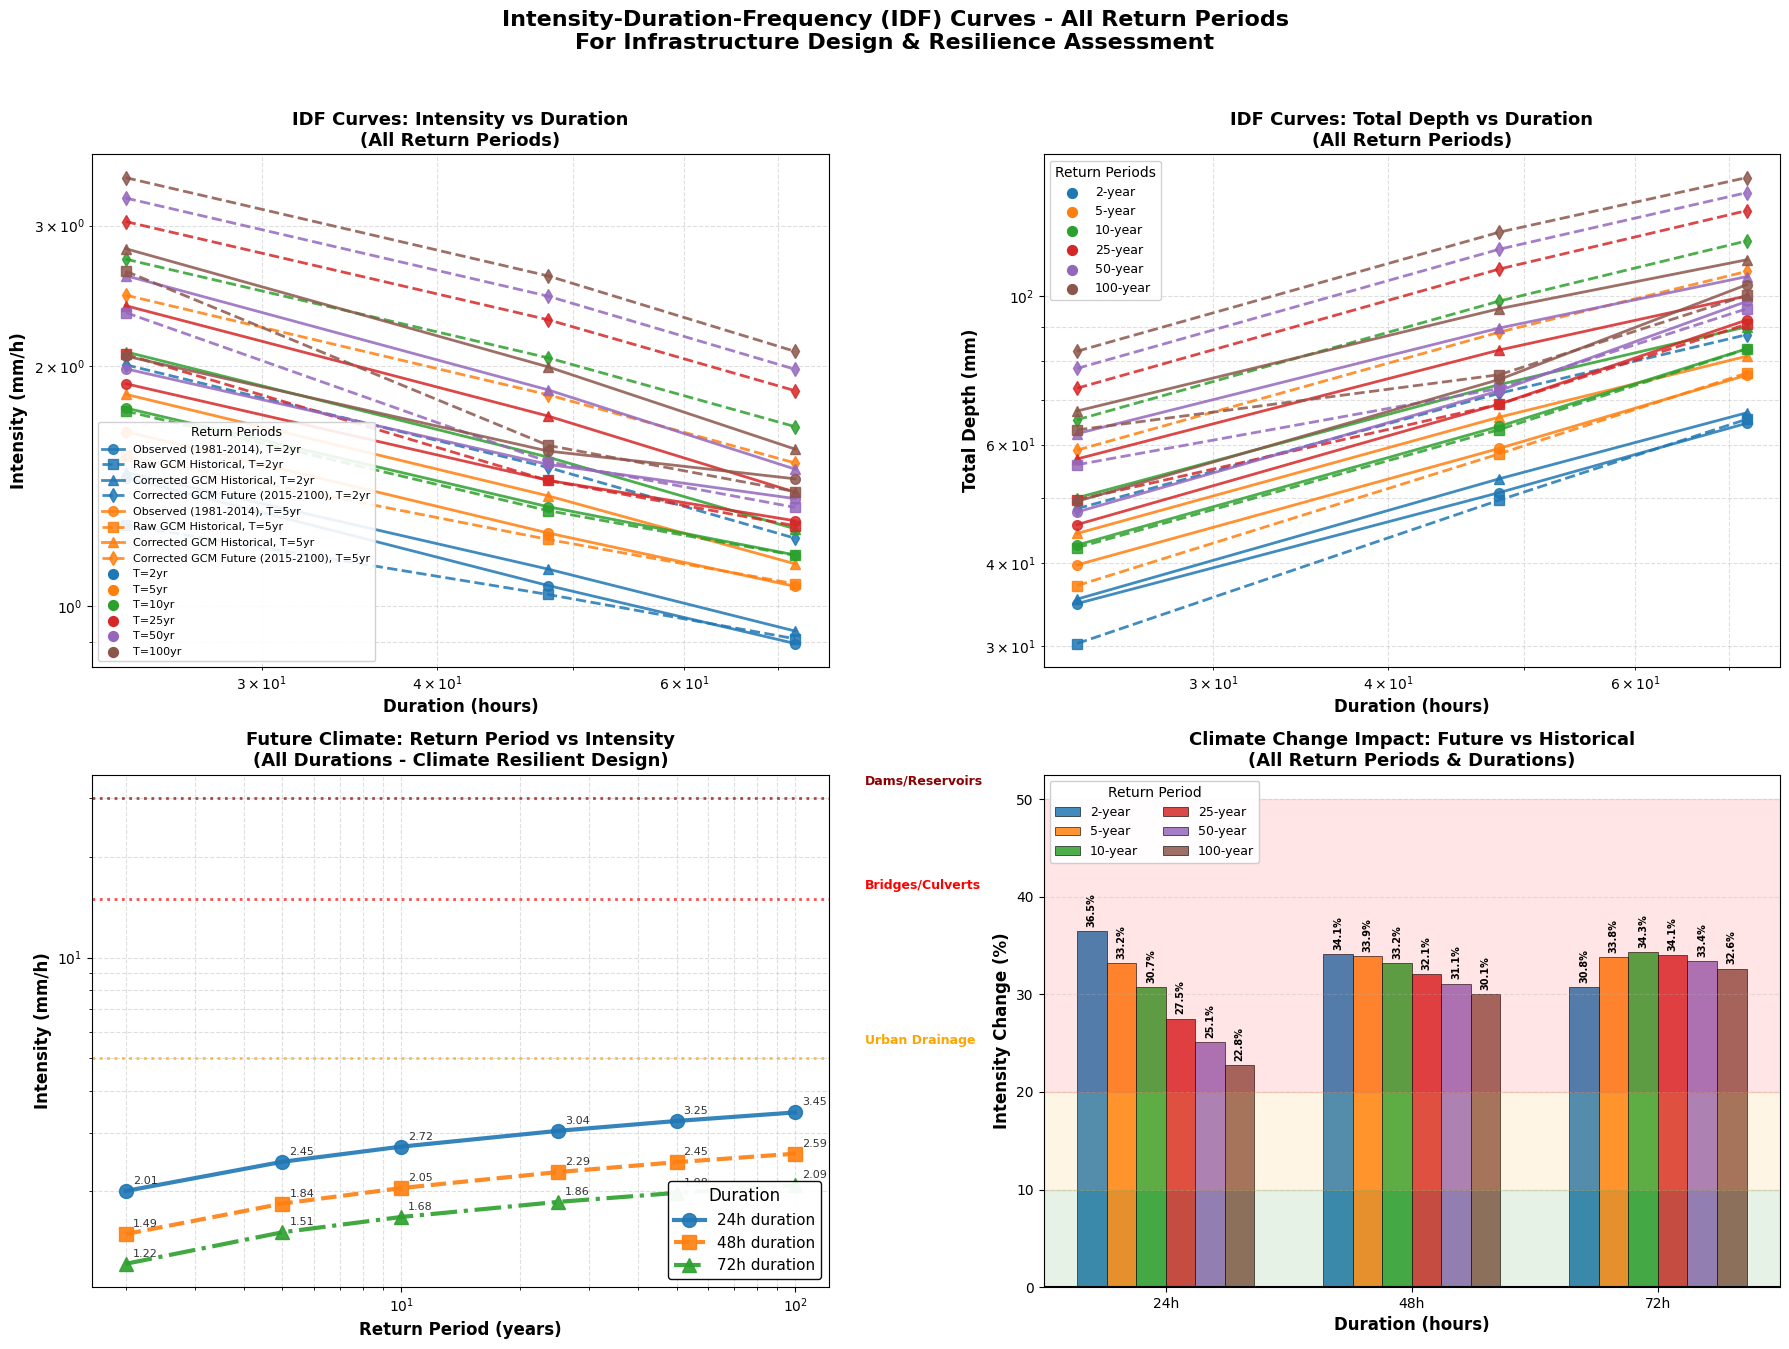

Saved dataset comparison to: /content/drive/MyDrive/Prof_data/output/04b_idf_curves_by_dataset.png


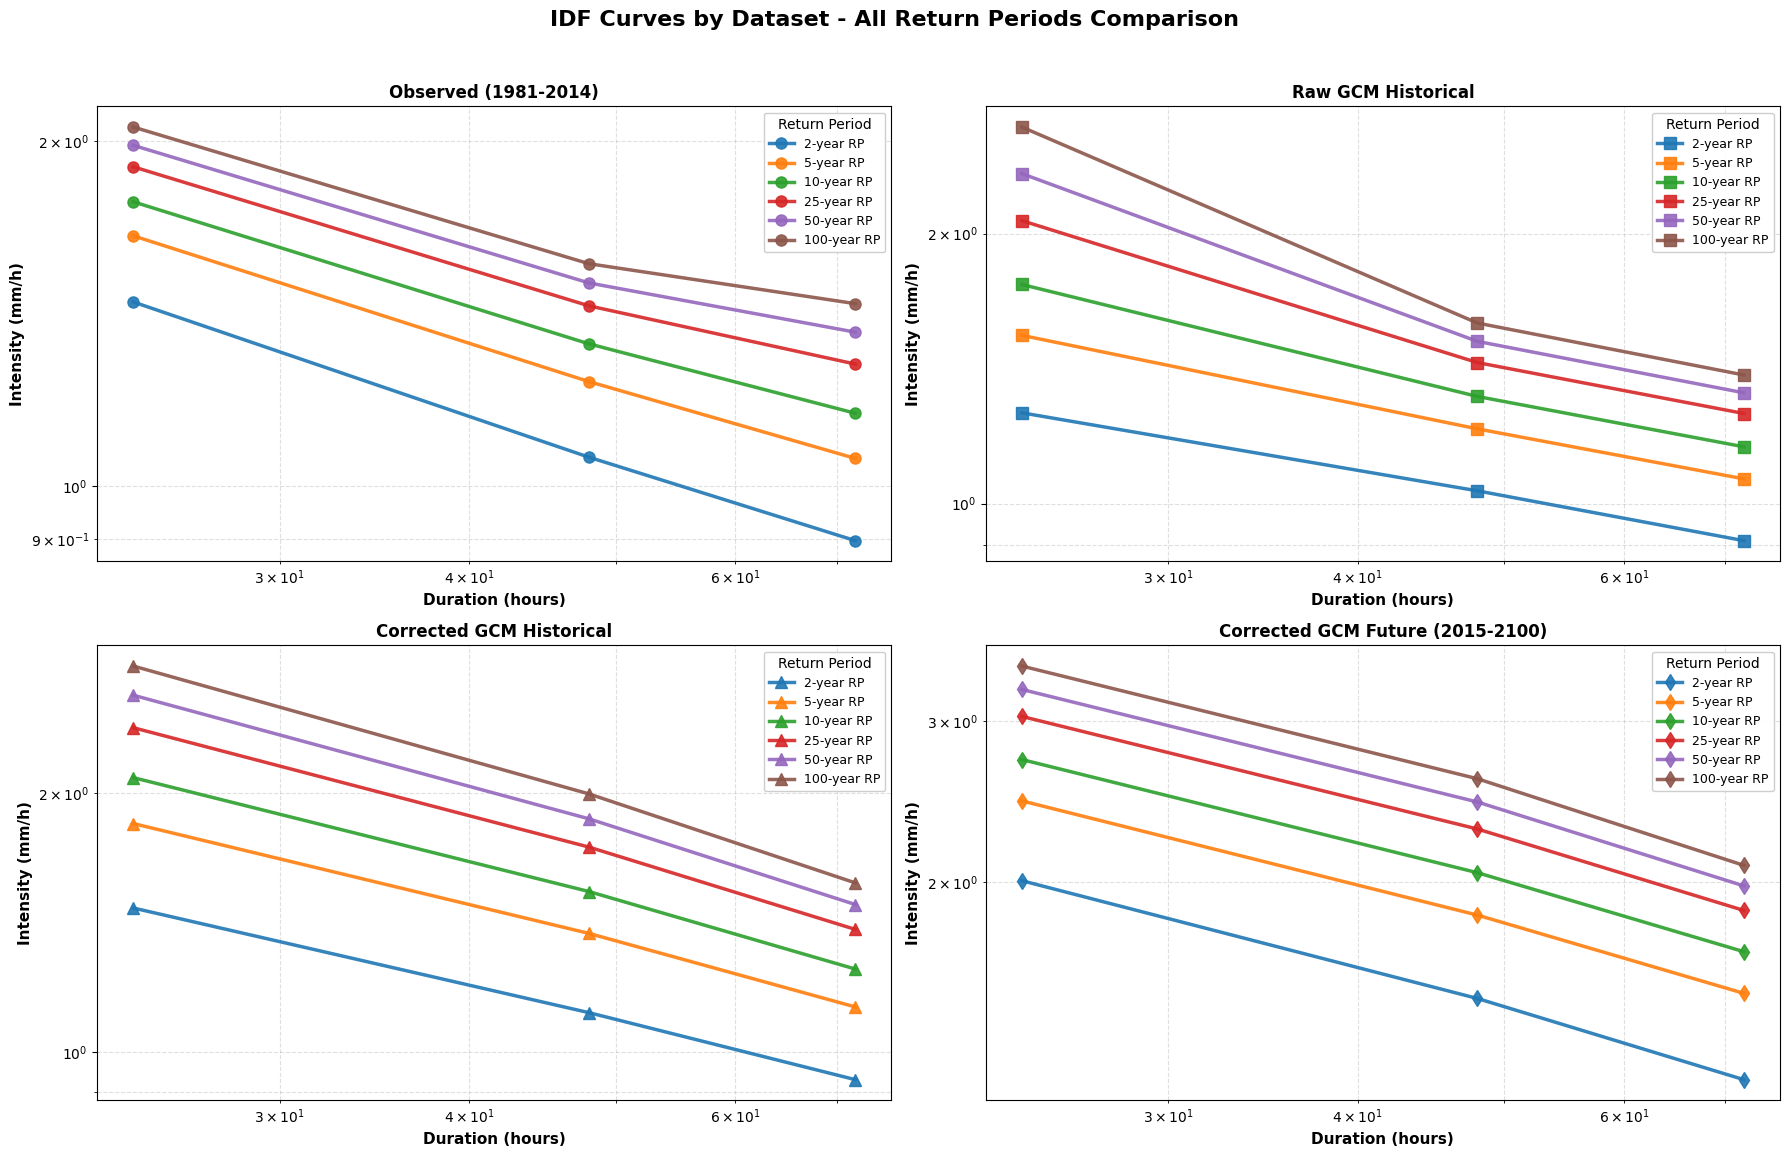

In [36]:
# CELL 15: PLOT IDF CURVES FOR INFRASTRUCTURE DESIGN - ALL RETURN PERIODS
# =============================================================================

def plot_idf_curves_all_return_periods(idf_df, output_dir):
    """
    Create comprehensive IDF curve plots showing all return periods distinctly.
    """
    # Create figure with 4 subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Intensity-Duration-Frequency (IDF) Curves - All Return Periods\nFor Infrastructure Design & Resilience Assessment',
                 fontsize=16, fontweight='bold', y=0.98)

    datasets = {
        'observed': ('Observed (1981-2014)', 'black', '-', 'o'),
        'gcm_hist_raw': ('Raw GCM Historical', 'red', '--', 's'),
        'gcm_hist_corrected': ('Corrected GCM Historical', 'blue', '-', '^'),
        'gcm_future_corrected': ('Corrected GCM Future (2015-2100)', 'green', '--', 'd')
    }

    # Define distinct colors for each return period
    rp_colors = {
        2: '#1f77b4',    # Blue
        5: '#ff7f0e',    # Orange
        10: '#2ca02c',   # Green
        25: '#d62728',   # Red
        50: '#9467bd',   # Purple
        100: '#8c564b'   # Brown
    }

    markers = ['o', 's', '^', 'D', 'v', 'p']

    # =========================================================================
    # PLOT 1: IDF Curves - Intensity vs Duration (All Return Periods)
    # =========================================================================
    ax1 = axes[0, 0]

    for i, T in enumerate(RETURN_PERIODS):
        color = rp_colors[T]
        marker = markers[i % len(markers)]

        for dataset, (label, ds_color, linestyle, ds_marker) in datasets.items():
            subset = idf_df[(idf_df['dataset'] == dataset) & (idf_df['return_period'] == T)]
            if not subset.empty:
                # Use return period color for line, dataset marker style
                ax1.plot(subset['duration'], subset['intensity'],
                        linestyle=linestyle, color=color,
                        marker=ds_marker, markersize=7, linewidth=2,
                        label=f'{label}, T={T}yr' if i < 2 else "",  # Limit legend entries
                        alpha=0.85)

    ax1.set_xlabel('Duration (hours)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Intensity (mm/h)', fontsize=12, fontweight='bold')
    ax1.set_title('IDF Curves: Intensity vs Duration\n(All Return Periods)',
                  fontsize=13, fontweight='bold')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.grid(True, alpha=0.4, which='both', linestyle='--')

    # Custom legend with two columns
    handles, labels = ax1.get_legend_handles_labels()
    # Create separate legends for datasets and return periods
    ax1.legend(handles[:4], labels[:4], loc='upper right', fontsize=8,
              title='Datasets', title_fontsize=9, framealpha=0.9)

    # Add return period color bar/legend
    for T, color in rp_colors.items():
        ax1.scatter([], [], c=color, s=50, label=f'T={T}yr')
    ax1.legend(loc='lower left', fontsize=8, title='Return Periods',
              title_fontsize=9, framealpha=0.9)

    # =========================================================================
    # PLOT 2: IDF Curves - Depth vs Duration (All Return Periods)
    # =========================================================================
    ax2 = axes[0, 1]

    for i, T in enumerate(RETURN_PERIODS):
        color = rp_colors[T]

        for dataset, (label, ds_color, linestyle, ds_marker) in datasets.items():
            subset = idf_df[(idf_df['dataset'] == dataset) & (idf_df['return_period'] == T)]
            if not subset.empty:
                ax2.plot(subset['duration'], subset['depth'],
                        linestyle=linestyle, color=color,
                        marker=ds_marker, markersize=7, linewidth=2,
                        alpha=0.85)

    ax2.set_xlabel('Duration (hours)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Total Depth (mm)', fontsize=12, fontweight='bold')
    ax2.set_title('IDF Curves: Total Depth vs Duration\n(All Return Periods)',
                  fontsize=13, fontweight='bold')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.4, which='both', linestyle='--')

    # Add return period legend
    for T, color in rp_colors.items():
        ax2.scatter([], [], c=color, s=50, label=f'{T}-year')
    ax2.legend(loc='upper left', fontsize=9, title='Return Periods',
              title_fontsize=10, framealpha=0.9)

    # =========================================================================
    # PLOT 3: Return Period vs Intensity for All Durations (Future Climate)
    # =========================================================================
    ax3 = axes[1, 0]

    # Focus on corrected future for design purposes
    future_data = idf_df[idf_df['dataset'] == 'gcm_future_corrected']

    duration_styles = {24: ('-', 'o'), 48: ('--', 's'), 72: ('-.', '^')}
    duration_colors = {24: '#1f77b4', 48: '#ff7f0e', 72: '#2ca02c'}

    for duration in DURATIONS:
        subset = future_data[future_data['duration'] == duration]
        if not subset.empty:
            linestyle, marker = duration_styles[duration]
            color = duration_colors[duration]

            ax3.plot(subset['return_period'], subset['intensity'],
                    linestyle=linestyle, color=color, marker=marker,
                    markersize=10, linewidth=3,
                    label=f'{duration}h duration', alpha=0.9)

            # Add value labels at each point
            for _, row in subset.iterrows():
                ax3.annotate(f'{row["intensity"]:.2f}',
                           xy=(row['return_period'], row['intensity']),
                           xytext=(5, 5), textcoords='offset points',
                           fontsize=8, alpha=0.8)

    ax3.set_xlabel('Return Period (years)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Intensity (mm/h)', fontsize=12, fontweight='bold')
    ax3.set_title('Future Climate: Return Period vs Intensity\n(All Durations - Climate Resilient Design)',
                  fontsize=13, fontweight='bold')
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.grid(True, alpha=0.4, which='both', linestyle='--')
    ax3.legend(loc='lower right', fontsize=11, title='Duration',
              title_fontsize=12, framealpha=0.95, edgecolor='black')

    # Add infrastructure design thresholds
    ax3.axhline(y=5, color='orange', linestyle=':', alpha=0.7, linewidth=2, label='Minor structures')
    ax3.axhline(y=15, color='red', linestyle=':', alpha=0.7, linewidth=2, label='Major infrastructure')
    ax3.axhline(y=30, color='darkred', linestyle=':', alpha=0.7, linewidth=2, label='Critical facilities')

    # Add text annotations for thresholds
    ax3.text(150, 5.5, 'Urban Drainage', fontsize=9, color='orange', fontweight='bold')
    ax3.text(150, 16, 'Bridges/Culverts', fontsize=9, color='red', fontweight='bold')
    ax3.text(150, 33, 'Dams/Reservoirs', fontsize=9, color='darkred', fontweight='bold')

    # =========================================================================
    # PLOT 4: Climate Change Impact - All Return Periods & Durations
    # =========================================================================
    ax4 = axes[1, 1]

    hist_data = idf_df[idf_df['dataset'] == 'gcm_hist_corrected']
    future_data = idf_df[idf_df['dataset'] == 'gcm_future_corrected']

    # Create grouped bar chart showing change for each duration and return period
    x = np.arange(len(DURATIONS))
    width = 0.12  # Width of bars
    multiplier = 0

    for i, T in enumerate(RETURN_PERIODS):
        color = rp_colors[T]
        offset = width * multiplier

        changes = []
        for duration in DURATIONS:
            h = hist_data[(hist_data['duration'] == duration) & (hist_data['return_period'] == T)]
            f = future_data[(future_data['duration'] == duration) & (future_data['return_period'] == T)]

            if not h.empty and not f.empty:
                change = ((f['intensity'].values[0] - h['intensity'].values[0])
                         / h['intensity'].values[0] * 100)
                changes.append(change)
            else:
                changes.append(0)

        rects = ax4.bar(x + offset, changes, width, label=f'{T}-year',
                       color=color, alpha=0.85, edgecolor='black', linewidth=0.5)

        # Add value labels on bars
        for rect, change in zip(rects, changes):
            height = rect.get_height()
            if abs(height) > 1:  # Only label significant changes
                ax4.annotate(f'{height:.1f}%',
                           xy=(rect.get_x() + rect.get_width() / 2, height),
                           xytext=(0, 3 if height > 0 else -12),
                           textcoords="offset points",
                           ha='center', va='bottom' if height > 0 else 'top',
                           fontsize=7, fontweight='bold', rotation=90 if abs(height) > 10 else 0)

        multiplier += 1

    ax4.set_xlabel('Duration (hours)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Intensity Change (%)', fontsize=12, fontweight='bold')
    ax4.set_title('Climate Change Impact: Future vs Historical\n(All Return Periods & Durations)',
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x + width * (len(RETURN_PERIODS) - 1) / 2)
    ax4.set_xticklabels([f'{d}h' for d in DURATIONS])
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
    ax4.legend(loc='upper left', fontsize=9, title='Return Period',
              title_fontsize=10, ncol=2, framealpha=0.95)

    # Add significance bands
    ax4.axhspan(0, 10, alpha=0.1, color='green', label='Low impact')
    ax4.axhspan(10, 20, alpha=0.1, color='orange', label='Moderate impact')
    ax4.axhspan(20, 50, alpha=0.1, color='red', label='High impact')

    plt.tight_layout(rect=[0, 0.02, 1, 0.96])

    output_file = os.path.join(output_dir, '04_idf_curves_all_return_periods.png')
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\nSaved comprehensive IDF curves to: {output_file}")
    plt.show()

    # =========================================================================
    # ADDITIONAL PLOT: Separate figure for each dataset showing all return periods
    # =========================================================================
    fig2, axes2 = plt.subplots(2, 2, figsize=(18, 12))
    fig2.suptitle('IDF Curves by Dataset - All Return Periods Comparison',
                  fontsize=16, fontweight='bold')

    for idx, (dataset, (label, ds_color, linestyle, marker)) in enumerate(datasets.items()):
        ax = axes2[idx // 2, idx % 2]

        dataset_data = idf_df[idf_df['dataset'] == dataset]

        for i, T in enumerate(RETURN_PERIODS):
            color = rp_colors[T]
            subset = dataset_data[dataset_data['return_period'] == T]

            if not subset.empty:
                ax.plot(subset['duration'], subset['intensity'],
                       linestyle='-', color=color, marker=marker,
                       markersize=8, linewidth=2.5,
                       label=f'{T}-year RP', alpha=0.9)

        ax.set_xlabel('Duration (hours)', fontsize=11, fontweight='bold')
        ax.set_ylabel('Intensity (mm/h)', fontsize=11, fontweight='bold')
        ax.set_title(f'{label}', fontsize=12, fontweight='bold')
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.4, which='both', linestyle='--')
        ax.legend(loc='upper right', fontsize=9, title='Return Period',
                title_fontsize=10, framealpha=0.95)

    plt.tight_layout(rect=[0, 0.02, 1, 0.96])

    output_file2 = os.path.join(output_dir, '04b_idf_curves_by_dataset.png')
    plt.savefig(output_file2, dpi=300, bbox_inches='tight')
    print(f"Saved dataset comparison to: {output_file2}")
    plt.show()

# Generate comprehensive IDF plots
plot_idf_curves_all_return_periods(idf_df, CONFIG['output_dir'])